<a href="https://colab.research.google.com/github/icmsol/capstone-project-5-generative-ai-applications/blob/main/generative_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project 5 - Generative AI Applications

## Transformer-Based Generation of Public-Sector Contract Language

This notebook implements and evaluates a small custom PyTorch causal Transformer trained on a frozen corpus of FAR Subpart 52.2 provisions and clauses. The purpose is to study generation behavior and responsible-use risks, not to produce legally valid contract language.

**Current notebook status:** Dataset acquisition, source-boundary correction, clause-level partitioning, character-vocabulary construction, and sequence preprocessing are complete. The next phases implement, train, and evaluate the causal Transformer and analyze its generated outputs and responsible-use risks.


## 1. Environment and Reproducibility

The workflow records package versions, random seeds, device information, and configuration values. A CUDA-capable Colab runtime is preferred, with automatic CPU fallback.

In [1]:
from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/icmsol/capstone-project-5-generative-ai-applications.git"
REPO_DIR = Path("/content/capstone-project-5-generative-ai-applications")

if REPO_DIR.exists():
    print("Repository already exists. Pulling the latest version...")
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "pull"],
        check=True,
    )
else:
    print("Cloning repository...")
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True,
    )

os.chdir(REPO_DIR)

print(f"Working directory: {Path.cwd()}")
print(f"Dataset found: {(REPO_DIR / 'data' / 'processed' / 'far_part_52_2_clauses.csv').exists()}")
print(f"Configuration found: {(REPO_DIR / 'config' / 'project_config.json').exists()}")

Cloning repository...
Working directory: /content/capstone-project-5-generative-ai-applications
Dataset found: True
Configuration found: True


In [2]:
from pathlib import Path
import json
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.12.13
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Load and Inspect the Dataset

The source is a frozen FAC 2026-01 snapshot of FAR Subpart 52.2, effective March 13, 2026. Reserved headings and the scope-only section were excluded during deterministic extraction. The processed CSV and source documentation are included in the repository.

In [3]:
def locate_repo_root() -> Path:
    candidates = [Path.cwd(), Path("/content/capstone-project-5-generative-ai-applications")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "far_part_52_2_clauses.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Dataset not found. Open the notebook from the repository root or clone the repository into /content."
    )

REPO_ROOT = locate_repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "far_part_52_2_clauses.csv"
AUDIT_PATH = REPO_ROOT / "data" / "audit" / "dataset_audit.json"
CONFIG_PATH = REPO_ROOT / "config" / "project_config.json"

df = pd.read_csv(DATA_PATH)
audit = json.loads(AUDIT_PATH.read_text(encoding="utf-8"))
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
display(df[["record_id", "clause_number", "title", "word_count", "char_count"]].head())

Records: 610
Columns: ['record_id', 'clause_number', 'title', 'family', 'reserved', 'word_count', 'char_count', 'text', 'has_underscore_fill', 'has_bracket_fill', 'source_fac', 'effective_date', 'source_pdf_pages']


,record_id,clause_number,title,word_count,char_count
0,FAR52_0001,52.201-1,Acquisition 360: Voluntary Survey.,150,992
1,FAR52_0002,52.202-1,Definitions.,170,1015
2,FAR52_0003,52.203-2,Certificate of Independent Price Determination.,424,2599
3,FAR52_0004,52.203-3,Gratuities.,228,1348
4,FAR52_0005,52.203-5,Covenant Against Contingent Fees.,289,1810


In [4]:
summary = pd.Series({
    "usable_records": len(df),
    "total_characters": int(df["char_count"].sum()),
    "total_words": int(df["word_count"].sum()),
    "median_words_per_record": float(df["word_count"].median()),
    "minimum_words": int(df["word_count"].min()),
    "maximum_words": int(df["word_count"].max()),
    "clause_families": int(df["family"].nunique()),
    "empty_records": int(df["text"].fillna("").str.strip().eq("").sum()),
    "duplicate_clause_numbers": int(df["clause_number"].duplicated().sum()),
    "duplicate_text_records": int(df["text"].duplicated().sum()),
})
display(summary.to_frame("value"))

,value
usable_records,610.0
total_characters,2207308.0
total_words,342400.0
median_words_per_record,291.5
minimum_words,41.0
maximum_words,8553.0
clause_families,45.0
empty_records,0.0
duplicate_clause_numbers,0.0
duplicate_text_records,0.0


In [5]:
import hashlib
import json
import re
from pathlib import Path

# Verify the corrected, committed dataset without modifying it.
CORPUS_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "far_part_52_2_corpus.txt"
)

MANIFEST_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "file_manifest.json"
)

SCRIPT_PATH = (
    REPO_ROOT
    / "src"
    / "extract_far_part52.py"
)

WORD_RE = re.compile(r"\b[\w’'-]+\b")

model_corpus = CORPUS_PATH.read_text(
    encoding="utf-8"
)

last_clause_text = df.loc[
    df["clause_number"].eq("52.253-1"),
    "text",
].iloc[0]

verified_statistics = {
    "records": len(df),
    "record_text_characters": int(
        df["text"].fillna("").str.len().sum()
    ),
    "record_text_word_tokens": int(
        sum(
            len(WORD_RE.findall(text))
            for text in df["text"].fillna("")
        )
    ),
    "model_corpus_characters": len(model_corpus),
    "model_corpus_word_tokens": len(
        WORD_RE.findall(model_corpus)
    ),
    "unique_model_corpus_word_tokens": len(
        {
            token.casefold()
            for token in WORD_RE.findall(model_corpus)
        }
    ),
    "empty_records": int(
        df["text"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    ),
    "duplicate_clause_numbers": int(
        df["clause_number"].duplicated().sum()
    ),
    "duplicate_text_records": int(
        df["text"].duplicated().sum()
    ),
    "part_52_3_spillover_records": int(
        df["text"]
        .str.contains(
            "SUBPART 52.3",
            regex=False,
            na=False,
        )
        .sum()
    ),
}

expected_statistics = {
    "records": 610,
    "record_text_characters": 2_207_308,
    "record_text_word_tokens": 342_400,
    "model_corpus_characters": 2_214_359,
    "model_corpus_word_tokens": 343_620,
    "unique_model_corpus_word_tokens": 8_513,
    "empty_records": 0,
    "duplicate_clause_numbers": 0,
    "duplicate_text_records": 0,
    "part_52_3_spillover_records": 0,
}

if verified_statistics != expected_statistics:
    raise AssertionError(
        "Corrected dataset statistics do not match "
        "the committed audit baseline.\n"
        f"Expected: {expected_statistics}\n"
        f"Found: {verified_statistics}"
    )

if not last_clause_text.rstrip().endswith(
    "(End of clause)"
):
    raise AssertionError(
        "The final FAR clause does not terminate "
        "at the expected boundary."
    )

if "SUBPART 52.3" in last_clause_text:
    raise AssertionError(
        "The final FAR clause still contains "
        "Subpart 52.3 spillover."
    )

verified_manifest = json.loads(
    MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

files_to_verify = {
    "data/audit/PHASE_1_DATASET_AUDIT.md":
        REPO_ROOT / "data" / "audit" / "PHASE_1_DATASET_AUDIT.md",
    "data/audit/dataset_audit.json":
        AUDIT_PATH,
    "data/processed/far_part_52_2_clauses.csv":
        DATA_PATH,
    "data/processed/far_part_52_2_corpus.txt":
        CORPUS_PATH,
    "src/extract_far_part52.py":
        SCRIPT_PATH,
}

for manifest_key, file_path in files_to_verify.items():
    calculated_hash = hashlib.sha256(
        file_path.read_bytes()
    ).hexdigest()

    recorded_hash = verified_manifest[
        manifest_key
    ]["sha256"]

    if calculated_hash != recorded_hash:
        raise AssertionError(
            f"Checksum mismatch: {manifest_key}"
        )

print("CORRECTED DATASET VERIFICATION: PASS")
print("-" * 62)

for metric, value in verified_statistics.items():
    print(f"{metric:38s} {value:,}")

print("-" * 62)
print("Final 52.253-1 boundary:              PASS")
print("Part 52.3 spillover:                  0")
print("Committed source-artifact checksums:  PASS")


CORRECTED DATASET VERIFICATION: PASS
--------------------------------------------------------------
records                                610
record_text_characters                 2,207,308
record_text_word_tokens                342,400
model_corpus_characters                2,214,359
model_corpus_word_tokens               343,620
unique_model_corpus_word_tokens        8,513
empty_records                          0
duplicate_clause_numbers               0
duplicate_text_records                 0
part_52_3_spillover_records            0
--------------------------------------------------------------
Final 52.253-1 boundary:              PASS
Part 52.3 spillover:                  0
Committed source-artifact checksums:  PASS


In [6]:
sample_columns = ["clause_number", "title", "text"]
sample_records = df.sample(3, random_state=SEED)[sample_columns]

for row in sample_records.itertuples(index=False):
    print("=" * 100)
    print(f"{row.clause_number} - {row.title}")
    print(row.text[:1_000])
    print()

52.211-11 - Liquidated Damages-Supplies, Services, or Research and Development.
Liquidated Damages-Supplies, Services, or Research and Development.
As prescribed in 11.503(a), insert the following clause in solicitations and contracts:

LIQUIDATED DAMAGES-SUPPLIES, SERVICES, OR RESEARCH AND DEVELOPMENT (SEPT 2000)

(a) If the Contractor fails to deliver the supplies or perform the services within the time specified in this contract, the
Contractor shall, in place of actual damages, pay to the Government liquidated damages of $__________ per calendar day of
delay [Contracting Officer insert amount].
(b) If the Government terminates this contract in whole or in part under the Default-Fixed-Price Supply and Service
clause, the Contractor is liable for liquidated damages accruing until the Government reasonably obtains delivery or
performance of similar supplies or services. These liquidated damages are in addition to excess costs of repurchase under the
Termination clause.
(c) The Contrac

### Dataset sufficiency conclusion

The corrected corpus contains 610 nonempty and unique provisions or clauses. The record text contains 2,207,308 characters and 342,400 word-like tokens; after adding clause-number prefixes and record separators, the model-ready corpus contains 2,214,359 characters and 343,620 word-like tokens. This is sufficient for a small character-level causal Transformer while remaining practical for a Colab T4. Because clause lengths are highly right-skewed, the train/validation/test split is performed at the complete-clause level before fixed-length sequence construction, and a per-record window cap prevents a few unusually long clauses from dominating training.


## 3. Preprocessing and Clause-Level Splitting

Complete provisions and clauses are assigned to training, validation, or held-out test partitions before fixed-length sequence windows are created. This prevents text from the same clause from appearing in more than one partition. A deterministic 80/10/10 procedure uses clause family, record length, and a seeded stable hash to distribute records reproducibly. The test partition remains untouched during model selection and is used only for final evaluation.


In [7]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

SPLIT_SEED = 42
SPLIT_ORDER = ["train", "validation", "test"]

# Work from the corrected record-level dataset.
split_df = df.copy()

# Confirm that the source records are valid before splitting.
if not split_df["record_id"].is_unique:
    raise ValueError(
        "record_id must be unique before splitting."
    )

if split_df["text"].fillna("").str.strip().eq("").any():
    raise ValueError(
        "Empty text records cannot be split."
    )

# Create five reproducible record-length groups.
# Ranking first prevents duplicate qcut boundaries.
length_labels = [
    "Q1_shortest",
    "Q2_short",
    "Q3_medium",
    "Q4_long",
    "Q5_longest",
]

split_df["length_bin"] = pd.qcut(
    split_df["word_count"].rank(method="first"),
    q=5,
    labels=length_labels,
)


def stable_hash(
    record_id: str,
    seed: int,
) -> int:
    """Create a deterministic hash for split ordering."""

    payload = f"{seed}|{record_id}".encode("utf-8")

    return int(
        hashlib.sha256(payload).hexdigest()[:16],
        16,
    )


split_df["_stable_hash"] = split_df[
    "record_id"
].map(
    lambda record_id: stable_hash(
        str(record_id),
        SPLIT_SEED,
    )
)

# Order records by clause family, length group, and stable hash.
# This distributes different clause families and lengths across
# the three partitions while remaining fully reproducible.
ordered = split_df.sort_values(
    [
        "family",
        "length_bin",
        "_stable_hash",
    ],
    kind="mergesort",
).copy()

# Exact repeating 80/10/10 assignment pattern:
# 8 training, 1 validation, and 1 test record per 10 records.
assignment_pattern = np.array(
    [
        "train",
        "validation",
        "train",
        "test",
        "train",
        "train",
        "train",
        "train",
        "train",
        "train",
    ]
)

ordered["split"] = assignment_pattern[
    np.arange(len(ordered))
    % len(assignment_pattern)
]

# Restore the original record order and remove the temporary hash.
split_df = (
    ordered
    .sort_index()
    .drop(columns=["_stable_hash"])
)

# ------------------------------------------------------------
# Integrity and leakage-control checks
# ------------------------------------------------------------

assert len(split_df) == 610
assert split_df["record_id"].is_unique
assert split_df["split"].notna().all()
assert set(split_df["split"]) == set(SPLIT_ORDER)

split_counts = (
    split_df["split"]
    .value_counts()
    .reindex(SPLIT_ORDER)
    .astype(int)
)

expected_counts = pd.Series(
    {
        "train": 488,
        "validation": 61,
        "test": 61,
    },
    dtype="int64",
)

if not split_counts.equals(expected_counts):
    raise AssertionError(
        "Unexpected split counts:\n"
        f"{split_counts}"
    )

# Verify that no record appears in more than one partition.
records_per_split = {
    split_name: set(
        split_df.loc[
            split_df["split"].eq(split_name),
            "record_id",
        ]
    )
    for split_name in SPLIT_ORDER
}

assert records_per_split["train"].isdisjoint(
    records_per_split["validation"]
)

assert records_per_split["train"].isdisjoint(
    records_per_split["test"]
)

assert records_per_split["validation"].isdisjoint(
    records_per_split["test"]
)

# ------------------------------------------------------------
# Split summaries
# ------------------------------------------------------------

split_summary = pd.DataFrame(
    {
        "records": split_counts,
        "percentage": (
            split_counts
            / len(split_df)
            * 100
        ).round(1),
        "characters": (
            split_df
            .groupby("split")["char_count"]
            .sum()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "word_like_tokens": (
            split_df
            .groupby("split")["word_count"]
            .sum()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "families_represented": (
            split_df
            .groupby("split")["family"]
            .nunique()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
    }
)

family_distribution = pd.crosstab(
    split_df["family"],
    split_df["split"],
).reindex(
    columns=SPLIT_ORDER,
    fill_value=0,
)

# This version avoids the unsupported observed= argument.
length_distribution = pd.crosstab(
    split_df["length_bin"],
    split_df["split"],
    dropna=False,
).reindex(
    index=length_labels,
    columns=SPLIT_ORDER,
    fill_value=0,
)

# ------------------------------------------------------------
# Save split datasets and audit evidence
# ------------------------------------------------------------

SPLIT_DATA_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "far_part_52_2_clauses_with_splits.csv"
)

SPLIT_ASSIGNMENTS_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "far_part_52_2_split_assignments.csv"
)

SPLIT_AUDIT_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase3_split_audit.json"
)

# Save the complete corrected records with split assignments.
split_df.to_csv(
    SPLIT_DATA_PATH,
    index=False,
    encoding="utf-8",
)

# Save a smaller assignment-only file for transparent review.
split_df[
    [
        "record_id",
        "clause_number",
        "family",
        "word_count",
        "char_count",
        "length_bin",
        "split",
    ]
].to_csv(
    SPLIT_ASSIGNMENTS_PATH,
    index=False,
    encoding="utf-8",
)

split_audit = {
    "split_seed": SPLIT_SEED,
    "split_method": (
        "Deterministic clause-level 80/10/10 assignment "
        "after family, length-bin, and stable-hash ordering."
    ),
    "leakage_control": (
        "Each complete clause is assigned to exactly one "
        "partition before fixed-length sequence-window "
        "construction. The held-out test partition is not "
        "used during training or model selection."
    ),
    "record_counts": {
        split_name: int(
            split_counts[split_name]
        )
        for split_name in SPLIT_ORDER
    },
    "percentages": {
        split_name: float(
            split_summary.loc[
                split_name,
                "percentage",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "characters": {
        split_name: int(
            split_summary.loc[
                split_name,
                "characters",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "word_like_tokens": {
        split_name: int(
            split_summary.loc[
                split_name,
                "word_like_tokens",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "families_represented": {
        split_name: int(
            split_summary.loc[
                split_name,
                "families_represented",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "integrity_checks": {
        "total_records": int(
            len(split_df)
        ),
        "unique_record_ids": int(
            split_df["record_id"].nunique()
        ),
        "unassigned_records": int(
            split_df["split"].isna().sum()
        ),
        "exact_text_duplicates": int(
            split_df["text"].duplicated().sum()
        ),
        "train_validation_overlap": int(
            len(
                records_per_split["train"]
                & records_per_split["validation"]
            )
        ),
        "train_test_overlap": int(
            len(
                records_per_split["train"]
                & records_per_split["test"]
            )
        ),
        "validation_test_overlap": int(
            len(
                records_per_split["validation"]
                & records_per_split["test"]
            )
        ),
    },
}

SPLIT_AUDIT_PATH.write_text(
    json.dumps(
        split_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("CLAUSE-LEVEL SPLIT: PASS")
print("-" * 64)

display(split_summary)

print()
print("Length-bin distribution")
display(length_distribution)

print()
print("Families represented in each partition")
print(
    split_summary[
        "families_represented"
    ].to_string()
)

print()
print("Leakage checks")
print("-" * 64)
print("Train-validation overlap: 0")
print("Train-test overlap:       0")
print("Validation-test overlap:  0")

print()
print("Saved artifacts")
print("-" * 64)
print(
    SPLIT_DATA_PATH.relative_to(
        REPO_ROOT
    )
)
print(
    SPLIT_ASSIGNMENTS_PATH.relative_to(
        REPO_ROOT
    )
)
print(
    SPLIT_AUDIT_PATH.relative_to(
        REPO_ROOT
    )
)

CLAUSE-LEVEL SPLIT: PASS
----------------------------------------------------------------


,records,percentage,characters,word_like_tokens,families_represented
split,,,,,
train,488,80.0,1740590,269982,43
validation,61,10.0,219276,34337,32
test,61,10.0,247442,38081,31



Length-bin distribution


split,train,validation,test
length_bin,,,
Q1_shortest,96,12,14
Q2_short,98,12,12
Q3_medium,101,13,8
Q4_long,93,13,16
Q5_longest,100,11,11



Families represented in each partition
split
train         43
validation    32
test          31

Leakage checks
----------------------------------------------------------------
Train-validation overlap: 0
Train-test overlap:       0
Validation-test overlap:  0

Saved artifacts
----------------------------------------------------------------
data/processed/far_part_52_2_clauses_with_splits.csv
data/processed/far_part_52_2_split_assignments.csv
data/audit/phase3_split_audit.json


In [8]:
from collections import Counter
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

# ------------------------------------------------------------
# Final preprocessing parameters
# ------------------------------------------------------------

CONTEXT_LENGTH = 256
SEQUENCE_STRIDE = 128
MAX_WINDOWS_PER_RECORD = 64

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Prefix each record with its official clause number.
# Windows are constructed within individual records only,
# so no sequence crosses from one clause into another.
split_df = split_df.copy()

split_df["model_text"] = split_df.apply(
    lambda row: (
        f"{row['clause_number']} "
        f"{str(row['text']).strip()}"
    ),
    axis=1,
)

if split_df["model_text"].str.len().lt(2).any():
    raise ValueError(
        "Every model-text record must contain at least "
        "two characters."
    )

# ------------------------------------------------------------
# Build the character vocabulary from training data only
# ------------------------------------------------------------

training_text = "".join(
    split_df.loc[
        split_df["split"].eq("train"),
        "model_text",
    ]
)

training_characters = sorted(
    set(training_text)
)

character_to_index = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for character in training_characters:
    character_to_index[character] = len(
        character_to_index
    )

index_to_character = {
    index: character
    for character, index
    in character_to_index.items()
}

PAD_INDEX = character_to_index[PAD_TOKEN]
UNK_INDEX = character_to_index[UNK_TOKEN]

VOCAB_SIZE = len(character_to_index)

# Identify any validation or test characters that were not
# observed in the training partition.
unseen_characters = {}

for split_name in SPLIT_ORDER:
    partition_text = "".join(
        split_df.loc[
            split_df["split"].eq(split_name),
            "model_text",
        ]
    )

    unseen_characters[split_name] = sorted(
        set(partition_text)
        - set(training_characters)
    )

# ------------------------------------------------------------
# Construct within-record fixed-length sequence windows
# ------------------------------------------------------------

sequence_rows = []

for row in split_df[
    [
        "record_id",
        "clause_number",
        "family",
        "split",
        "model_text",
    ]
].itertuples(index=False):

    record_text = row.model_text
    record_length = len(record_text)

    if record_length < 2:
        continue

    # Standard sliding-window starting points.
    candidate_starts = list(
        range(
            0,
            max(record_length - 1, 1),
            SEQUENCE_STRIDE,
        )
    )

    # Ensure the end of each clause is represented.
    final_start = max(
        0,
        record_length
        - (CONTEXT_LENGTH + 1),
    )

    candidate_starts.append(final_start)

    candidate_starts = sorted(
        set(candidate_starts)
    )

    # Prevent unusually long clauses from dominating training.
    # When a record has too many possible windows, retain evenly
    # spaced positions across the full clause.
    if (
        len(candidate_starts)
        > MAX_WINDOWS_PER_RECORD
    ):
        selected_positions = np.linspace(
            0,
            len(candidate_starts) - 1,
            num=MAX_WINDOWS_PER_RECORD,
            dtype=int,
        )

        candidate_starts = [
            candidate_starts[position]
            for position in sorted(
                set(selected_positions.tolist())
            )
        ]

    for start_position in candidate_starts:
        available_transitions = min(
            CONTEXT_LENGTH,
            record_length
            - 1
            - start_position,
        )

        if available_transitions <= 0:
            continue

        sequence_rows.append(
            {
                "record_id": row.record_id,
                "clause_number": row.clause_number,
                "family": row.family,
                "split": row.split,
                "start_position": int(
                    start_position
                ),
                "valid_tokens": int(
                    available_transitions
                ),
                "padded_tokens": int(
                    CONTEXT_LENGTH
                    - available_transitions
                ),
                "is_padded": bool(
                    available_transitions
                    < CONTEXT_LENGTH
                ),
            }
        )

sequence_index_df = pd.DataFrame(
    sequence_rows
)

if sequence_index_df.empty:
    raise ValueError(
        "No sequence windows were created."
    )

# ------------------------------------------------------------
# Sequence and leakage checks
# ------------------------------------------------------------

records_represented = (
    sequence_index_df.groupby("split")[
        "record_id"
    ]
    .nunique()
    .reindex(SPLIT_ORDER)
)

expected_records_represented = (
    split_df.groupby("split")[
        "record_id"
    ]
    .nunique()
    .reindex(SPLIT_ORDER)
)

if not records_represented.equals(
    expected_records_represented
):
    raise AssertionError(
        "At least one source record is missing from "
        "the sequence index."
    )

# Every sequence belongs to exactly one source record and split.
sequence_split_check = (
    sequence_index_df.groupby("record_id")[
        "split"
    ]
    .nunique()
)

if not sequence_split_check.eq(1).all():
    raise AssertionError(
        "A record appears in multiple sequence partitions."
    )

# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

record_text_lookup = (
    split_df.set_index("record_id")[
        "model_text"
    ]
    .to_dict()
)


class CharacterWindowDataset(Dataset):
    """Fixed-length character windows within complete clauses."""

    def __init__(
        self,
        sequence_index: pd.DataFrame,
        record_lookup: dict,
        char_to_index: dict,
        context_length: int,
        pad_index: int,
        unk_index: int,
    ):
        self.sequence_index = (
            sequence_index
            .reset_index(drop=True)
            .copy()
        )

        self.record_lookup = record_lookup
        self.char_to_index = char_to_index
        self.context_length = context_length
        self.pad_index = pad_index
        self.unk_index = unk_index

    def __len__(self):
        return len(self.sequence_index)

    def __getitem__(self, item):
        metadata = self.sequence_index.iloc[item]

        record_id = metadata["record_id"]
        start_position = int(
            metadata["start_position"]
        )

        record_text = self.record_lookup[
            record_id
        ]

        segment = record_text[
            start_position:
            start_position
            + self.context_length
            + 1
        ]

        encoded = [
            self.char_to_index.get(
                character,
                self.unk_index,
            )
            for character in segment
        ]

        input_ids = encoded[:-1]
        target_ids = encoded[1:]

        valid_length = len(input_ids)

        if valid_length < self.context_length:
            padding_length = (
                self.context_length
                - valid_length
            )

            input_ids.extend(
                [self.pad_index]
                * padding_length
            )

            target_ids.extend(
                [self.pad_index]
                * padding_length
            )

        input_tensor = torch.tensor(
            input_ids,
            dtype=torch.long,
        )

        target_tensor = torch.tensor(
            target_ids,
            dtype=torch.long,
        )

        return input_tensor, target_tensor


datasets = {}

for split_name in SPLIT_ORDER:
    partition_index = sequence_index_df.loc[
        sequence_index_df["split"].eq(
            split_name
        )
    ]

    datasets[split_name] = (
        CharacterWindowDataset(
            sequence_index=partition_index,
            record_lookup=record_text_lookup,
            char_to_index=character_to_index,
            context_length=CONTEXT_LENGTH,
            pad_index=PAD_INDEX,
            unk_index=UNK_INDEX,
        )
    )

train_dataset = datasets["train"]
validation_dataset = datasets["validation"]
test_dataset = datasets["test"]

# ------------------------------------------------------------
# Save vocabulary, sequence index, configuration, and audit
# ------------------------------------------------------------

VOCAB_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "character_vocabulary.json"
)

SEQUENCE_INDEX_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "sequence_windows.csv"
)

SEQUENCE_AUDIT_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase3_sequence_audit.json"
)

vocabulary_payload = {
    "vocabulary_type": "character",
    "built_from_partition": "train",
    "special_tokens": {
        "pad_token": PAD_TOKEN,
        "pad_index": PAD_INDEX,
        "unknown_token": UNK_TOKEN,
        "unknown_index": UNK_INDEX,
    },
    "training_character_count": len(
        training_characters
    ),
    "total_vocabulary_size": VOCAB_SIZE,
    "characters": training_characters,
    "character_to_index": character_to_index,
}

VOCAB_PATH.write_text(
    json.dumps(
        vocabulary_payload,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    encoding="utf-8",
)

sequence_index_df.to_csv(
    SEQUENCE_INDEX_PATH,
    index=False,
    encoding="utf-8",
)

window_summary = pd.DataFrame(
    {
        "windows": (
            sequence_index_df.groupby("split")
            .size()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "records_represented": (
            sequence_index_df.groupby("split")[
                "record_id"
            ]
            .nunique()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "padded_windows": (
            sequence_index_df.groupby("split")[
                "is_padded"
            ]
            .sum()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "average_valid_tokens": (
            sequence_index_df.groupby("split")[
                "valid_tokens"
            ]
            .mean()
            .reindex(SPLIT_ORDER)
            .round(1)
        ),
        "maximum_windows_per_record": (
            sequence_index_df.groupby(
                ["split", "record_id"]
            )
            .size()
            .groupby("split")
            .max()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
    }
)

all_families = set(
    split_df["family"].astype(str)
)

training_families = set(
    split_df.loc[
        split_df["split"].eq("train"),
        "family",
    ].astype(str)
)

families_missing_from_training = sorted(
    all_families - training_families
)

sequence_audit = {
    "context_length": CONTEXT_LENGTH,
    "stride": SEQUENCE_STRIDE,
    "maximum_windows_per_record": (
        MAX_WINDOWS_PER_RECORD
    ),
    "vocabulary_built_from": (
        "training partition only"
    ),
    "training_character_count": len(
        training_characters
    ),
    "total_vocabulary_size": VOCAB_SIZE,
    "unseen_characters_by_partition": {
        split_name: unseen_characters[
            split_name
        ]
        for split_name in SPLIT_ORDER
    },
    "window_counts": {
        split_name: int(
            window_summary.loc[
                split_name,
                "windows",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "records_represented": {
        split_name: int(
            window_summary.loc[
                split_name,
                "records_represented",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "families_missing_from_training": (
        families_missing_from_training
    ),
    "controls": {
        "cross_clause_windows": False,
        "test_used_for_model_selection": False,
        "long_record_window_cap": (
            MAX_WINDOWS_PER_RECORD
        ),
        "padding_loss_policy": (
            "PAD index will be ignored by "
            "cross-entropy loss."
        ),
    },
}

SEQUENCE_AUDIT_PATH.write_text(
    json.dumps(
        sequence_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# Record finalized preprocessing values in project configuration.
config["preprocessing"] = {
    "split_seed": SPLIT_SEED,
    "split_ratio": {
        "train": 0.80,
        "validation": 0.10,
        "test": 0.10,
    },
    "context_length": CONTEXT_LENGTH,
    "stride": SEQUENCE_STRIDE,
    "maximum_windows_per_record": (
        MAX_WINDOWS_PER_RECORD
    ),
    "vocabulary_type": "character",
    "vocabulary_source": (
        "training partition only"
    ),
    "pad_index": PAD_INDEX,
    "unknown_index": UNK_INDEX,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# ------------------------------------------------------------
# Smoke-test encoding and dataset output
# ------------------------------------------------------------

sample_input, sample_target = train_dataset[0]

assert sample_input.shape == (
    CONTEXT_LENGTH,
)

assert sample_target.shape == (
    CONTEXT_LENGTH,
)

assert sample_input.dtype == torch.long
assert sample_target.dtype == torch.long


def decode_indices(
    indices,
    skip_padding=True,
):
    characters = []

    for index in indices:
        token = index_to_character[
            int(index)
        ]

        if (
            skip_padding
            and token == PAD_TOKEN
        ):
            continue

        if token == UNK_TOKEN:
            characters.append("�")
        else:
            characters.append(token)

    return "".join(characters)


decoded_input = decode_indices(
    sample_input[:300]
)

decoded_target = decode_indices(
    sample_target[:300]
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "CHARACTER VOCABULARY AND "
    "SEQUENCE PIPELINE: PASS"
)

print("-" * 72)

print(
    f"Training characters: "
    f"{len(training_characters):,}"
)

print(
    f"Total vocabulary size: "
    f"{VOCAB_SIZE:,}"
)

print(
    f"Validation unseen characters: "
    f"{len(unseen_characters['validation']):,}"
)

print(
    f"Test unseen characters: "
    f"{len(unseen_characters['test']):,}"
)

print(
    "Families missing from training: "
    f"{families_missing_from_training}"
)

print()
display(window_summary)

print()
print(
    f"Training sample tensor shape: "
    f"{tuple(sample_input.shape)}"
)

print()
print("Decoded input preview")
print("-" * 72)
print(repr(decoded_input[:300]))

print()
print("Decoded target preview")
print("-" * 72)
print(repr(decoded_target[:300]))

print()
print("Saved artifacts")
print("-" * 72)

print(
    VOCAB_PATH.relative_to(
        REPO_ROOT
    )
)

print(
    SEQUENCE_INDEX_PATH.relative_to(
        REPO_ROOT
    )
)

print(
    SEQUENCE_AUDIT_PATH.relative_to(
        REPO_ROOT
    )
)

print(
    CONFIG_PATH.relative_to(
        REPO_ROOT
    )
)

CHARACTER VOCABULARY AND SEQUENCE PIPELINE: PASS
------------------------------------------------------------------------
Training characters: 94
Total vocabulary size: 96
Validation unseen characters: 1
Test unseen characters: 2
Families missing from training: ['202', '239']



,windows,records_represented,padded_windows,average_valid_tokens,maximum_windows_per_record
split,,,,,
train,11489,488,924,245.3,64
validation,1408,61,119,245.1,64
test,1444,61,114,245.8,64



Training sample tensor shape: (256,)

Decoded input preview
------------------------------------------------------------------------
'52.201-1 Acquisition 360: Voluntary Survey.\nAs prescribed in 1.102-3(b), insert the following provision:\n\nACQUISITION 360: VOLUNTARY SURVEY (SEP 2023)\n\n(a) All actual and potential offerors are encouraged to provide feedback on the preaward and debriefing '

Decoded target preview
------------------------------------------------------------------------
'2.201-1 Acquisition 360: Voluntary Survey.\nAs prescribed in 1.102-3(b), insert the following provision:\n\nACQUISITION 360: VOLUNTARY SURVEY (SEP 2023)\n\n(a) All actual and potential offerors are encouraged to provide feedback on the preaward and debriefing p'

Saved artifacts
------------------------------------------------------------------------
data/processed/character_vocabulary.json
data/processed/sequence_windows.csv
data/audit/phase3_sequence_audit.json
config/project_config.json


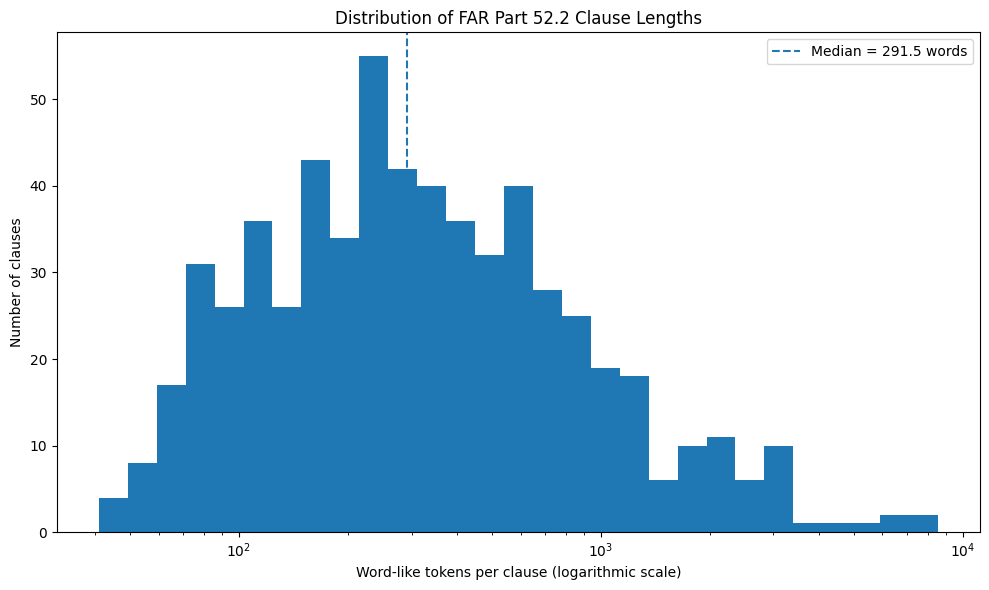

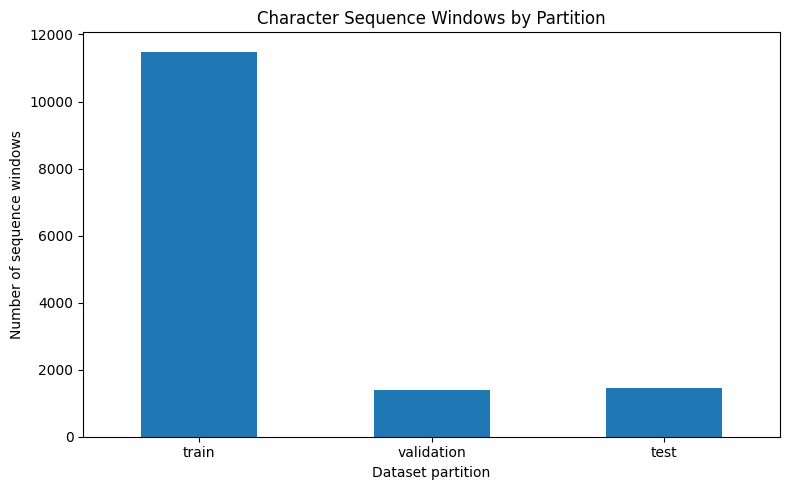

PHASE 3 VISUALIZATION AND ARTIFACT AUDIT: PASS
------------------------------------------------------------------------
Clause-length figure: figures/phase3_clause_length_distribution.png
Sequence-window figure: figures/phase3_sequence_windows_by_split.png
Phase 3 audit: data/audit/PHASE_3_PREPROCESSING_AUDIT.md
Manifest: data/audit/file_manifest.json
All Phase 3 artifact checksums: PASS


In [9]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CLAUSE_LENGTH_FIGURE_PATH = (
    FIGURES_DIR
    / "phase3_clause_length_distribution.png"
)

WINDOW_COUNT_FIGURE_PATH = (
    FIGURES_DIR
    / "phase3_sequence_windows_by_split.png"
)

PHASE3_AUDIT_MD_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "PHASE_3_PREPROCESSING_AUDIT.md"
)

MANIFEST_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "file_manifest.json"
)

# ------------------------------------------------------------
# Figure 1: clause-length distribution
# ------------------------------------------------------------

word_counts = (
    split_df["word_count"]
    .astype(int)
)

minimum_words = int(
    word_counts.min()
)

maximum_words = int(
    word_counts.max()
)

median_words = float(
    word_counts.median()
)

log_bins = np.logspace(
    np.log10(minimum_words),
    np.log10(maximum_words),
    num=30,
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    word_counts,
    bins=log_bins,
)

plt.xscale("log")

plt.axvline(
    median_words,
    linestyle="--",
    label=(
        f"Median = "
        f"{median_words:,.1f} words"
    ),
)

plt.title(
    "Distribution of FAR Part 52.2 Clause Lengths"
)

plt.xlabel(
    "Word-like tokens per clause "
    "(logarithmic scale)"
)

plt.ylabel(
    "Number of clauses"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    CLAUSE_LENGTH_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Figure 2: sequence-window counts
# ------------------------------------------------------------

window_counts_for_plot = (
    window_summary.loc[
        SPLIT_ORDER,
        "windows",
    ]
)

plt.figure(
    figsize=(8, 5)
)

window_counts_for_plot.plot(
    kind="bar",
)

plt.title(
    "Character Sequence Windows by Partition"
)

plt.xlabel(
    "Dataset partition"
)

plt.ylabel(
    "Number of sequence windows"
)

plt.xticks(
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    WINDOW_COUNT_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Create human-readable Phase 3 audit
# ------------------------------------------------------------

validation_unseen_display = json.dumps(
    unseen_characters["validation"],
    ensure_ascii=True,
)

test_unseen_display = json.dumps(
    unseen_characters["test"],
    ensure_ascii=True,
)

missing_families_display = (
    ", ".join(
        families_missing_from_training
    )
    if families_missing_from_training
    else "None"
)

phase3_audit_markdown = f"""# Phase 3 Preprocessing and Sequence Audit

## Clause-Level Split

| Partition | Records | Percentage | Characters | Word-Like Tokens | Families Represented |
|---|---:|---:|---:|---:|---:|
| Train | {int(split_summary.loc["train", "records"]):,} | {float(split_summary.loc["train", "percentage"]):.1f}% | {int(split_summary.loc["train", "characters"]):,} | {int(split_summary.loc["train", "word_like_tokens"]):,} | {int(split_summary.loc["train", "families_represented"]):,} |
| Validation | {int(split_summary.loc["validation", "records"]):,} | {float(split_summary.loc["validation", "percentage"]):.1f}% | {int(split_summary.loc["validation", "characters"]):,} | {int(split_summary.loc["validation", "word_like_tokens"]):,} | {int(split_summary.loc["validation", "families_represented"]):,} |
| Test | {int(split_summary.loc["test", "records"]):,} | {float(split_summary.loc["test", "percentage"]):.1f}% | {int(split_summary.loc["test", "characters"]):,} | {int(split_summary.loc["test", "word_like_tokens"]):,} | {int(split_summary.loc["test", "families_represented"]):,} |

The split was performed at the complete-clause level before sequence-window construction. Record overlap between all partition pairs is zero. The test partition is held out from model selection.

## Character Vocabulary

- Vocabulary source: training partition only
- Training characters: {len(training_characters):,}
- Special tokens: 2 (`<PAD>` and `<UNK>`)
- Total vocabulary size: {VOCAB_SIZE:,}
- Validation-only characters: {validation_unseen_display}
- Test-only characters: {test_unseen_display}
- Families absent from training: {missing_families_display}

Rare validation or test characters not observed in training are mapped to `<UNK>`. Building the vocabulary from training data only prevents information from held-out records from influencing preprocessing.

## Sequence Construction

| Partition | Windows | Records Represented | Padded Windows | Average Valid Tokens | Maximum Windows per Record |
|---|---:|---:|---:|---:|---:|
| Train | {int(window_summary.loc["train", "windows"]):,} | {int(window_summary.loc["train", "records_represented"]):,} | {int(window_summary.loc["train", "padded_windows"]):,} | {float(window_summary.loc["train", "average_valid_tokens"]):.1f} | {int(window_summary.loc["train", "maximum_windows_per_record"]):,} |
| Validation | {int(window_summary.loc["validation", "windows"]):,} | {int(window_summary.loc["validation", "records_represented"]):,} | {int(window_summary.loc["validation", "padded_windows"]):,} | {float(window_summary.loc["validation", "average_valid_tokens"]):.1f} | {int(window_summary.loc["validation", "maximum_windows_per_record"]):,} |
| Test | {int(window_summary.loc["test", "windows"]):,} | {int(window_summary.loc["test", "records_represented"]):,} | {int(window_summary.loc["test", "padded_windows"]):,} | {float(window_summary.loc["test", "average_valid_tokens"]):.1f} | {int(window_summary.loc["test", "maximum_windows_per_record"]):,} |

- Context length: {CONTEXT_LENGTH:,} characters
- Sequence stride: {SEQUENCE_STRIDE:,} characters
- Maximum windows per record: {MAX_WINDOWS_PER_RECORD:,}
- Cross-clause sequence windows: prohibited
- Padding loss policy: padding targets will be ignored by the cross-entropy loss
- Long-clause control: evenly spaced windows are retained across the full clause when the cap is reached

## Phase 3 Conclusion

The corrected FAR corpus has been divided into reproducible, leakage-controlled train, validation, and held-out test partitions. The character vocabulary was derived exclusively from training records. The sequence pipeline retains coverage across every source record while limiting the influence of unusually long clauses. The artifacts are ready for Transformer implementation and smoke testing.
"""

PHASE3_AUDIT_MD_PATH.write_text(
    phase3_audit_markdown,
    encoding="utf-8",
)

# ------------------------------------------------------------
# Update the integrity manifest
# ------------------------------------------------------------

if MANIFEST_PATH.exists():
    manifest = json.loads(
        MANIFEST_PATH.read_text(
            encoding="utf-8"
        )
    )
else:
    manifest = {}

phase3_artifacts = {
    (
        "config/"
        "project_config.json"
    ): CONFIG_PATH,

    (
        "data/audit/"
        "PHASE_3_PREPROCESSING_AUDIT.md"
    ): PHASE3_AUDIT_MD_PATH,

    (
        "data/audit/"
        "phase3_split_audit.json"
    ): (
        REPO_ROOT
        / "data"
        / "audit"
        / "phase3_split_audit.json"
    ),

    (
        "data/audit/"
        "phase3_sequence_audit.json"
    ): (
        REPO_ROOT
        / "data"
        / "audit"
        / "phase3_sequence_audit.json"
    ),

    (
        "data/processed/"
        "far_part_52_2_clauses_with_splits.csv"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "far_part_52_2_clauses_with_splits.csv"
    ),

    (
        "data/processed/"
        "far_part_52_2_split_assignments.csv"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "far_part_52_2_split_assignments.csv"
    ),

    (
        "data/processed/"
        "character_vocabulary.json"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "character_vocabulary.json"
    ),

    (
        "data/processed/"
        "sequence_windows.csv"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "sequence_windows.csv"
    ),

    (
        "figures/"
        "phase3_clause_length_distribution.png"
    ): CLAUSE_LENGTH_FIGURE_PATH,

    (
        "figures/"
        "phase3_sequence_windows_by_split.png"
    ): WINDOW_COUNT_FIGURE_PATH,
}

for relative_path, artifact_path in (
    phase3_artifacts.items()
):
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing Phase 3 artifact: "
            f"{artifact_path}"
        )

    payload = artifact_path.read_bytes()

    manifest[relative_path] = {
        "bytes": len(payload),
        "sha256": hashlib.sha256(
            payload
        ).hexdigest(),
    }

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# Verify the newly written manifest entries.
for relative_path, artifact_path in (
    phase3_artifacts.items()
):
    calculated_hash = hashlib.sha256(
        artifact_path.read_bytes()
    ).hexdigest()

    recorded_hash = manifest[
        relative_path
    ]["sha256"]

    if calculated_hash != recorded_hash:
        raise AssertionError(
            f"Checksum mismatch: "
            f"{relative_path}"
        )

print(
    "PHASE 3 VISUALIZATION AND "
    "ARTIFACT AUDIT: PASS"
)

print("-" * 72)

print(
    f"Clause-length figure: "
    f"{CLAUSE_LENGTH_FIGURE_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Sequence-window figure: "
    f"{WINDOW_COUNT_FIGURE_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Phase 3 audit: "
    f"{PHASE3_AUDIT_MD_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Manifest: "
    f"{MANIFEST_PATH.relative_to(REPO_ROOT)}"
)

print(
    "All Phase 3 artifact checksums: PASS"
)

## 4. Transformer Architecture and Training

A compact decoder-style causal Transformer is implemented directly in PyTorch. Character and learned positional embeddings feed a stack of masked self-attention blocks. The causal mask prevents each position from accessing future characters, while the padding mask excludes padded context positions. The output projection shares weights with the character embedding layer. Phase 4 validates tensor shapes, causal behavior, loss computation, gradients, and a short optimization smoke test before full training begins in Phase 5.

In [10]:
from dataclasses import asdict, dataclass
import json
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@dataclass(frozen=True)
class TransformerConfig:
    """Configuration for the character-level causal Transformer."""

    vocab_size: int
    context_length: int
    pad_index: int

    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 4
    dim_feedforward: int = 512
    dropout: float = 0.10

    def __post_init__(self):
        if self.vocab_size <= 2:
            raise ValueError(
                "vocab_size must include more than "
                "the two special tokens."
            )

        if self.context_length <= 0:
            raise ValueError(
                "context_length must be positive."
            )

        if self.d_model % self.n_heads != 0:
            raise ValueError(
                "d_model must be divisible by n_heads."
            )

        if not 0.0 <= self.dropout < 1.0:
            raise ValueError(
                "dropout must be in the interval [0, 1)."
            )


class CausalCharacterTransformer(nn.Module):
    """Decoder-style Transformer for next-character prediction."""

    def __init__(
        self,
        model_config: TransformerConfig,
    ):
        super().__init__()

        self.model_config = model_config

        self.token_embedding = nn.Embedding(
            num_embeddings=model_config.vocab_size,
            embedding_dim=model_config.d_model,
            padding_idx=model_config.pad_index,
        )

        self.position_embedding = nn.Embedding(
            num_embeddings=model_config.context_length,
            embedding_dim=model_config.d_model,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_config.d_model,
            nhead=model_config.n_heads,
            dim_feedforward=model_config.dim_feedforward,
            dropout=model_config.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=model_config.n_layers,
            norm=nn.LayerNorm(
                model_config.d_model
            ),
            enable_nested_tensor=False,
        )

        self.embedding_dropout = nn.Dropout(
            model_config.dropout
        )

        self.language_model_head = nn.Linear(
            model_config.d_model,
            model_config.vocab_size,
            bias=False,
        )

        # Weight tying reduces parameters and links input and
        # output character representations.
        self.language_model_head.weight = (
            self.token_embedding.weight
        )

        causal_mask = torch.triu(
            torch.ones(
                model_config.context_length,
                model_config.context_length,
                dtype=torch.bool,
            ),
            diagonal=1,
        )

        self.register_buffer(
            "causal_mask",
            causal_mask,
            persistent=False,
        )

        self._initialize_embeddings()

    def _initialize_embeddings(self):
        nn.init.normal_(
            self.token_embedding.weight,
            mean=0.0,
            std=0.02,
        )

        nn.init.normal_(
            self.position_embedding.weight,
            mean=0.0,
            std=0.02,
        )

        with torch.no_grad():
            self.token_embedding.weight[
                self.model_config.pad_index
            ].zero_()

    def forward(
        self,
        input_ids: torch.Tensor,
    ) -> torch.Tensor:
        if input_ids.ndim != 2:
            raise ValueError(
                "input_ids must have shape "
                "(batch_size, sequence_length)."
            )

        batch_size, sequence_length = (
            input_ids.shape
        )

        if sequence_length > (
            self.model_config.context_length
        ):
            raise ValueError(
                f"Sequence length {sequence_length} "
                "exceeds configured context length "
                f"{self.model_config.context_length}."
            )

        position_ids = torch.arange(
            sequence_length,
            device=input_ids.device,
        ).unsqueeze(0)

        position_ids = position_ids.expand(
            batch_size,
            sequence_length,
        )

        hidden_states = (
            self.token_embedding(input_ids)
            + self.position_embedding(
                position_ids
            )
        )

        hidden_states = self.embedding_dropout(
            hidden_states
        )

        active_causal_mask = self.causal_mask[
            :sequence_length,
            :sequence_length,
        ]

        padding_mask = input_ids.eq(
            self.model_config.pad_index
        )

        hidden_states = self.transformer(
            hidden_states,
            mask=active_causal_mask,
            src_key_padding_mask=padding_mask,
            is_causal=True,
        )

        logits = self.language_model_head(
            hidden_states
        )

        return logits


# ------------------------------------------------------------
# Instantiate the baseline architecture
# ------------------------------------------------------------

MODEL_CONFIG = TransformerConfig(
    vocab_size=VOCAB_SIZE,
    context_length=CONTEXT_LENGTH,
    pad_index=PAD_INDEX,
    d_model=128,
    n_heads=4,
    n_layers=4,
    dim_feedforward=512,
    dropout=0.10,
)

model = CausalCharacterTransformer(
    MODEL_CONFIG
).to(DEVICE)

loss_function = nn.CrossEntropyLoss(
    ignore_index=PAD_INDEX
)

# ------------------------------------------------------------
# Forward-pass smoke test
# ------------------------------------------------------------

SMOKE_BATCH_SIZE = 4

smoke_loader = DataLoader(
    train_dataset,
    batch_size=SMOKE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

smoke_inputs, smoke_targets = next(
    iter(smoke_loader)
)

smoke_inputs = smoke_inputs.to(
    DEVICE
)

smoke_targets = smoke_targets.to(
    DEVICE
)

model.eval()

with torch.no_grad():
    smoke_logits = model(
        smoke_inputs
    )

    smoke_loss = loss_function(
        smoke_logits.reshape(
            -1,
            MODEL_CONFIG.vocab_size,
        ),
        smoke_targets.reshape(-1),
    )

expected_logit_shape = (
    SMOKE_BATCH_SIZE,
    CONTEXT_LENGTH,
    VOCAB_SIZE,
)

if tuple(smoke_logits.shape) != (
    expected_logit_shape
):
    raise AssertionError(
        "Unexpected logits shape. "
        f"Expected {expected_logit_shape}, "
        f"found {tuple(smoke_logits.shape)}."
    )

if not torch.isfinite(smoke_logits).all():
    raise AssertionError(
        "The forward pass produced "
        "non-finite logits."
    )

if not torch.isfinite(smoke_loss):
    raise AssertionError(
        "The forward pass produced "
        "a non-finite loss."
    )

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

embedding_parameters = (
    model.token_embedding.weight.numel()
    + model.position_embedding.weight.numel()
)

parameter_memory_mb = (
    total_parameters
    * 4
    / 1_000_000
)

# ------------------------------------------------------------
# Persist the finalized architecture configuration
# ------------------------------------------------------------

config["model"] = {
    **asdict(MODEL_CONFIG),
    "architecture": (
        "Custom character-level causal Transformer"
    ),
    "activation": "GELU",
    "normalization": "pre-layer normalization",
    "weight_tying": True,
    "loss_function": (
        "CrossEntropyLoss with PAD ignored"
    ),
    "total_parameters": int(
        total_parameters
    ),
    "trainable_parameters": int(
        trainable_parameters
    ),
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# ------------------------------------------------------------
# Display smoke-test results
# ------------------------------------------------------------

print(
    "CAUSAL TRANSFORMER "
    "FORWARD-PASS SMOKE TEST: PASS"
)

print("-" * 72)

print(
    f"Device:                 {DEVICE}"
)

if torch.cuda.is_available():
    print(
        "GPU:                    "
        f"{torch.cuda.get_device_name(0)}"
    )

print(
    f"Vocabulary size:        "
    f"{MODEL_CONFIG.vocab_size:,}"
)

print(
    f"Context length:         "
    f"{MODEL_CONFIG.context_length:,}"
)

print(
    f"Model dimension:        "
    f"{MODEL_CONFIG.d_model:,}"
)

print(
    f"Attention heads:        "
    f"{MODEL_CONFIG.n_heads:,}"
)

print(
    f"Transformer layers:     "
    f"{MODEL_CONFIG.n_layers:,}"
)

print(
    f"Feed-forward dimension: "
    f"{MODEL_CONFIG.dim_feedforward:,}"
)

print(
    f"Dropout:                "
    f"{MODEL_CONFIG.dropout:.2f}"
)

print(
    f"Total parameters:       "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters:   "
    f"{trainable_parameters:,}"
)

print(
    f"Embedding parameters:   "
    f"{embedding_parameters:,}"
)

print(
    f"Parameter memory:       "
    f"{parameter_memory_mb:.2f} MB"
)

print(
    f"Input tensor shape:     "
    f"{tuple(smoke_inputs.shape)}"
)

print(
    f"Target tensor shape:    "
    f"{tuple(smoke_targets.shape)}"
)

print(
    f"Logits tensor shape:    "
    f"{tuple(smoke_logits.shape)}"
)

print(
    f"Initial smoke loss:     "
    f"{smoke_loss.item():.6f}"
)

print("-" * 72)

print(
    "Causal attention mask: PASS"
)

print(
    "Padding-aware loss:    PASS"
)

print(
    "Finite logits/loss:    PASS"
)

print(
    f"Saved configuration:   "
    f"{CONFIG_PATH.relative_to(REPO_ROOT)}"
)

CAUSAL TRANSFORMER FORWARD-PASS SMOKE TEST: PASS
------------------------------------------------------------------------
Device:                 cuda
GPU:                    Tesla T4
Vocabulary size:        96
Context length:         256
Model dimension:        128
Attention heads:        4
Transformer layers:     4
Feed-forward dimension: 512
Dropout:                0.10
Total parameters:       838,400
Trainable parameters:   838,400
Embedding parameters:   45,056
Parameter memory:       3.35 MB
Input tensor shape:     (4, 256)
Target tensor shape:    (4, 256)
Logits tensor shape:    (4, 256, 96)
Initial smoke loss:     4.573635
------------------------------------------------------------------------
Causal attention mask: PASS
Padding-aware loss:    PASS
Finite logits/loss:    PASS
Saved configuration:   config/project_config.json


In [11]:
import json
import math
import time

import torch
from torch.utils.data import DataLoader


# ============================================================
# 1. Strict causal-invariance test
# ============================================================

# Select a full-length, non-padded training window.
full_window_positions = (
    train_dataset.sequence_index.index[
        train_dataset.sequence_index[
            "valid_tokens"
        ].eq(CONTEXT_LENGTH)
    ]
    .tolist()
)

if not full_window_positions:
    raise ValueError(
        "No full-length training window is available "
        "for the causal-invariance test."
    )

causal_input, _ = train_dataset[
    full_window_positions[0]
]

causal_input = (
    causal_input
    .unsqueeze(0)
    .to(DEVICE)
)

modified_input = causal_input.clone()

# Change only the second half of the input.
# Positions before this boundary must produce identical logits.
change_start = CONTEXT_LENGTH // 2

modified_suffix = modified_input[
    :,
    change_start:,
]

# Deterministically replace characters while avoiding
# the PAD and UNK special-token indices.
modified_suffix = (
    2
    + (
        modified_suffix
        - 2
        + 7
    )
    % (
        VOCAB_SIZE
        - 2
    )
)

modified_input[
    :,
    change_start:,
] = modified_suffix

model.eval()

with torch.no_grad():
    original_logits = model(
        causal_input
    )

    modified_logits = model(
        modified_input
    )

prefix_max_difference = (
    original_logits[
        :,
        :change_start,
        :,
    ]
    - modified_logits[
        :,
        :change_start,
        :,
    ]
).abs().max().item()

suffix_max_difference = (
    original_logits[
        :,
        change_start:,
        :,
    ]
    - modified_logits[
        :,
        change_start:,
        :,
    ]
).abs().max().item()

CAUSAL_TOLERANCE = 1e-6

if prefix_max_difference > CAUSAL_TOLERANCE:
    raise AssertionError(
        "Future-token changes affected earlier logits. "
        f"Maximum prefix difference: "
        f"{prefix_max_difference:.10f}"
    )

if suffix_max_difference <= CAUSAL_TOLERANCE:
    raise AssertionError(
        "The suffix perturbation did not affect any "
        "permitted later logits."
    )


# ============================================================
# 2. Gradient-flow and short optimization smoke test
# ============================================================

# Use a fresh model so this smoke test does not alter the
# baseline model that will later be trained in Phase 5.
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

optimization_model = (
    CausalCharacterTransformer(
        MODEL_CONFIG
    )
    .to(DEVICE)
)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

optimization_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

optimization_inputs, optimization_targets = next(
    iter(optimization_loader)
)

optimization_inputs = optimization_inputs.to(
    DEVICE,
    non_blocking=True,
)

optimization_targets = optimization_targets.to(
    DEVICE,
    non_blocking=True,
)

smoke_optimizer = torch.optim.AdamW(
    optimization_model.parameters(),
    lr=2e-3,
    betas=(0.9, 0.95),
    weight_decay=0.01,
)

SMOKE_OPTIMIZATION_STEPS = 25
MAX_GRADIENT_NORM = 1.0

# Evaluate the fresh model before optimization.
optimization_model.eval()

with torch.no_grad():
    initial_optimization_logits = (
        optimization_model(
            optimization_inputs
        )
    )

    initial_optimization_loss = (
        loss_function(
            initial_optimization_logits.reshape(
                -1,
                MODEL_CONFIG.vocab_size,
            ),
            optimization_targets.reshape(-1),
        )
    ).item()

step_losses = []
first_step_gradient_norm = None
nonzero_gradient_tensors = None
all_gradients_finite = None

optimization_start_time = time.perf_counter()

optimization_model.train()

for step_number in range(
    1,
    SMOKE_OPTIMIZATION_STEPS + 1,
):
    smoke_optimizer.zero_grad(
        set_to_none=True
    )

    optimization_logits = (
        optimization_model(
            optimization_inputs
        )
    )

    optimization_loss = loss_function(
        optimization_logits.reshape(
            -1,
            MODEL_CONFIG.vocab_size,
        ),
        optimization_targets.reshape(-1),
    )

    if not torch.isfinite(
        optimization_loss
    ):
        raise AssertionError(
            "The optimization smoke test produced "
            "a non-finite loss."
        )

    optimization_loss.backward()

    if step_number == 1:
        gradient_tensors = [
            parameter.grad
            for parameter
            in optimization_model.parameters()
            if parameter.grad is not None
        ]

        nonzero_gradient_tensors = sum(
            int(
                gradient.detach()
                .abs()
                .max()
                .item()
                > 0.0
            )
            for gradient in gradient_tensors
        )

        all_gradients_finite = all(
            bool(
                torch.isfinite(
                    gradient
                ).all()
            )
            for gradient in gradient_tensors
        )

        first_step_gradient_norm = float(
            torch.sqrt(
                sum(
                    gradient.detach()
                    .float()
                    .pow(2)
                    .sum()
                    for gradient
                    in gradient_tensors
                )
            ).item()
        )

        if nonzero_gradient_tensors == 0:
            raise AssertionError(
                "No nonzero gradients were produced."
            )

        if not all_gradients_finite:
            raise AssertionError(
                "At least one gradient contains "
                "a non-finite value."
            )

    torch.nn.utils.clip_grad_norm_(
        optimization_model.parameters(),
        max_norm=MAX_GRADIENT_NORM,
    )

    smoke_optimizer.step()

    step_losses.append(
        float(
            optimization_loss.item()
        )
    )

optimization_seconds = (
    time.perf_counter()
    - optimization_start_time
)

# Evaluate after the short optimization run.
optimization_model.eval()

with torch.no_grad():
    final_optimization_logits = (
        optimization_model(
            optimization_inputs
        )
    )

    final_optimization_loss = (
        loss_function(
            final_optimization_logits.reshape(
                -1,
                MODEL_CONFIG.vocab_size,
            ),
            optimization_targets.reshape(-1),
        )
    ).item()

loss_reduction = (
    initial_optimization_loss
    - final_optimization_loss
)

loss_reduction_percentage = (
    loss_reduction
    / initial_optimization_loss
    * 100
)

if final_optimization_loss >= (
    initial_optimization_loss
):
    raise AssertionError(
        "The short optimization test did not "
        "reduce the fixed-batch loss."
    )


# ============================================================
# 3. Save Phase 4 smoke-test evidence
# ============================================================

PHASE4_SMOKE_AUDIT_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase4_model_smoke_audit.json"
)

phase4_smoke_audit = {
    "status": "PASS",
    "device": str(DEVICE),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "architecture": {
        "vocabulary_size":
            MODEL_CONFIG.vocab_size,
        "context_length":
            MODEL_CONFIG.context_length,
        "model_dimension":
            MODEL_CONFIG.d_model,
        "attention_heads":
            MODEL_CONFIG.n_heads,
        "transformer_layers":
            MODEL_CONFIG.n_layers,
        "feedforward_dimension":
            MODEL_CONFIG.dim_feedforward,
        "dropout":
            MODEL_CONFIG.dropout,
        "total_parameters":
            int(total_parameters),
    },
    "causality_test": {
        "changed_suffix_start_position":
            change_start,
        "prefix_max_difference":
            prefix_max_difference,
        "suffix_max_difference":
            suffix_max_difference,
        "tolerance":
            CAUSAL_TOLERANCE,
        "result":
            "PASS",
    },
    "gradient_test": {
        "nonzero_gradient_tensors":
            int(nonzero_gradient_tensors),
        "all_gradients_finite":
            bool(all_gradients_finite),
        "first_step_gradient_norm":
            first_step_gradient_norm,
        "gradient_clip_norm":
            MAX_GRADIENT_NORM,
        "result":
            "PASS",
    },
    "optimization_test": {
        "batch_size":
            int(
                optimization_inputs.shape[0]
            ),
        "steps":
            SMOKE_OPTIMIZATION_STEPS,
        "initial_loss":
            initial_optimization_loss,
        "final_loss":
            final_optimization_loss,
        "loss_reduction":
            loss_reduction,
        "loss_reduction_percentage":
            loss_reduction_percentage,
        "elapsed_seconds":
            optimization_seconds,
        "result":
            "PASS",
    },
}

PHASE4_SMOKE_AUDIT_PATH.write_text(
    json.dumps(
        phase4_smoke_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

config["phase4_smoke_test"] = {
    "status": "PASS",
    "causal_invariance_verified": True,
    "finite_nonzero_gradients_verified": True,
    "short_optimization_steps":
        SMOKE_OPTIMIZATION_STEPS,
    "short_optimization_loss_reduced":
        True,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 4. Release temporary GPU resources
# ============================================================

del optimization_model
del optimization_inputs
del optimization_targets
del optimization_logits
del final_optimization_logits
del initial_optimization_logits

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 5. Display results
# ============================================================

print(
    "CAUSALITY, GRADIENT, AND "
    "OPTIMIZATION SMOKE TEST: PASS"
)

print("-" * 74)

print("Causal-invariance test")
print(
    f"Changed suffix begins:      "
    f"position {change_start}"
)
print(
    f"Maximum prefix difference:  "
    f"{prefix_max_difference:.10f}"
)
print(
    f"Maximum suffix difference:  "
    f"{suffix_max_difference:.10f}"
)
print(
    "Future-to-past leakage:     NONE"
)

print()
print("Gradient-flow test")
print(
    f"Nonzero gradient tensors:   "
    f"{nonzero_gradient_tensors:,}"
)
print(
    f"All gradients finite:       "
    f"{all_gradients_finite}"
)
print(
    f"Initial gradient norm:      "
    f"{first_step_gradient_norm:.6f}"
)
print(
    f"Gradient clipping norm:     "
    f"{MAX_GRADIENT_NORM:.2f}"
)

print()
print("Fixed-batch optimization test")
print(
    f"Optimization steps:         "
    f"{SMOKE_OPTIMIZATION_STEPS:,}"
)
print(
    f"Initial loss:               "
    f"{initial_optimization_loss:.6f}"
)
print(
    f"Final loss:                 "
    f"{final_optimization_loss:.6f}"
)
print(
    f"Loss reduction:             "
    f"{loss_reduction:.6f}"
)
print(
    f"Loss reduction percentage:  "
    f"{loss_reduction_percentage:.2f}%"
)
print(
    f"Elapsed time:               "
    f"{optimization_seconds:.2f} seconds"
)

print("-" * 74)

print(
    "Saved smoke audit:         "
    f"{PHASE4_SMOKE_AUDIT_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Updated configuration:     "
    f"{CONFIG_PATH.relative_to(REPO_ROOT)}"
)

CAUSALITY, GRADIENT, AND OPTIMIZATION SMOKE TEST: PASS
--------------------------------------------------------------------------
Causal-invariance test
Changed suffix begins:      position 128
Maximum prefix difference:  0.0000000000
Maximum suffix difference:  0.2911112309
Future-to-past leakage:     NONE

Gradient-flow test
Nonzero gradient tensors:   52
All gradients finite:       True
Initial gradient norm:      3.757951
Gradient clipping norm:     1.00

Fixed-batch optimization test
Optimization steps:         25
Initial loss:               4.614851
Final loss:                 3.128065
Loss reduction:             1.486786
Loss reduction percentage:  32.22%
Elapsed time:               0.92 seconds
--------------------------------------------------------------------------
Saved smoke audit:         data/audit/phase4_model_smoke_audit.json
Updated configuration:     config/project_config.json


In [12]:
import copy
import json
import time
from pathlib import Path

import torch
from torch.utils.data import DataLoader


# ============================================================
# 1. Reusable training and evaluation helpers
# ============================================================

def move_batch_to_device(
    batch,
    device,
):
    input_ids, target_ids = batch

    return (
        input_ids.to(
            device,
            non_blocking=True,
        ),
        target_ids.to(
            device,
            non_blocking=True,
        ),
    )


@torch.no_grad()
def evaluate_batches(
    evaluation_model,
    data_loader,
    loss_fn,
    device,
    maximum_batches=None,
):
    evaluation_model.eval()

    total_loss = 0.0
    total_valid_tokens = 0
    processed_batches = 0

    for batch_number, batch in enumerate(
        data_loader,
        start=1,
    ):
        if (
            maximum_batches is not None
            and batch_number > maximum_batches
        ):
            break

        input_ids, target_ids = (
            move_batch_to_device(
                batch,
                device,
            )
        )

        logits = evaluation_model(
            input_ids
        )

        valid_token_count = int(
            target_ids.ne(PAD_INDEX).sum().item()
        )

        batch_loss = loss_fn(
            logits.reshape(
                -1,
                MODEL_CONFIG.vocab_size,
            ),
            target_ids.reshape(-1),
        )

        if not torch.isfinite(batch_loss):
            raise AssertionError(
                "Evaluation produced a non-finite loss."
            )

        total_loss += (
            float(batch_loss.item())
            * valid_token_count
        )

        total_valid_tokens += valid_token_count
        processed_batches += 1

    if processed_batches == 0:
        raise ValueError(
            "Evaluation processed no batches."
        )

    if total_valid_tokens == 0:
        raise ValueError(
            "Evaluation found no valid target tokens."
        )

    average_loss = (
        total_loss
        / total_valid_tokens
    )

    perplexity = math.exp(
        min(
            average_loss,
            20.0,
        )
    )

    return {
        "average_loss": average_loss,
        "perplexity": perplexity,
        "valid_tokens": total_valid_tokens,
        "batches": processed_batches,
    }


def train_limited_batches(
    training_model,
    data_loader,
    optimizer,
    loss_fn,
    device,
    maximum_batches,
    gradient_clip_norm,
):
    training_model.train()

    step_losses = []
    valid_token_counts = []
    gradient_norms = []

    training_start = time.perf_counter()

    for batch_number, batch in enumerate(
        data_loader,
        start=1,
    ):
        if batch_number > maximum_batches:
            break

        input_ids, target_ids = (
            move_batch_to_device(
                batch,
                device,
            )
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = training_model(
            input_ids
        )

        loss = loss_fn(
            logits.reshape(
                -1,
                MODEL_CONFIG.vocab_size,
            ),
            target_ids.reshape(-1),
        )

        if not torch.isfinite(loss):
            raise AssertionError(
                "Training produced a non-finite loss."
            )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                training_model.parameters(),
                max_norm=gradient_clip_norm,
            )
        )

        if not torch.isfinite(
            gradient_norm
        ):
            raise AssertionError(
                "Training produced a non-finite "
                "gradient norm."
            )

        optimizer.step()

        step_losses.append(
            float(loss.item())
        )

        valid_token_counts.append(
            int(
                target_ids.ne(
                    PAD_INDEX
                ).sum().item()
            )
        )

        gradient_norms.append(
            float(
                gradient_norm.item()
            )
        )

    elapsed_seconds = (
        time.perf_counter()
        - training_start
    )

    if not step_losses:
        raise ValueError(
            "Training processed no batches."
        )

    return {
        "step_losses": step_losses,
        "valid_token_counts":
            valid_token_counts,
        "gradient_norms":
            gradient_norms,
        "elapsed_seconds":
            elapsed_seconds,
        "processed_batches":
            len(step_losses),
    }


# ============================================================
# 2. Deterministic smoke-test loaders
# ============================================================

PHASE4_BATCH_SIZE = 16
PHASE4_TRAIN_BATCHES = 50
PHASE4_VALIDATION_BATCHES = 20
PHASE4_LEARNING_RATE = 1e-3
PHASE4_GRADIENT_CLIP = 1.0

phase4_loader_generator = (
    torch.Generator()
)

phase4_loader_generator.manual_seed(
    SEED
)

phase4_train_loader = DataLoader(
    train_dataset,
    batch_size=PHASE4_BATCH_SIZE,
    shuffle=True,
    generator=phase4_loader_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

phase4_validation_loader = DataLoader(
    validation_dataset,
    batch_size=PHASE4_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 3. Fresh model and pre-training validation
# ============================================================

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

phase4_model = (
    CausalCharacterTransformer(
        MODEL_CONFIG
    )
    .to(DEVICE)
)

phase4_optimizer = torch.optim.AdamW(
    phase4_model.parameters(),
    lr=PHASE4_LEARNING_RATE,
    betas=(0.9, 0.95),
    weight_decay=0.01,
)

validation_before = evaluate_batches(
    evaluation_model=phase4_model,
    data_loader=phase4_validation_loader,
    loss_fn=loss_function,
    device=DEVICE,
    maximum_batches=PHASE4_VALIDATION_BATCHES,
)


# ============================================================
# 4. Limited multi-batch training smoke test
# ============================================================

training_smoke_result = (
    train_limited_batches(
        training_model=phase4_model,
        data_loader=phase4_train_loader,
        optimizer=phase4_optimizer,
        loss_fn=loss_function,
        device=DEVICE,
        maximum_batches=PHASE4_TRAIN_BATCHES,
        gradient_clip_norm=PHASE4_GRADIENT_CLIP,
    )
)

validation_after = evaluate_batches(
    evaluation_model=phase4_model,
    data_loader=phase4_validation_loader,
    loss_fn=loss_function,
    device=DEVICE,
    maximum_batches=PHASE4_VALIDATION_BATCHES,
)

validation_loss_reduction = (
    validation_before["average_loss"]
    - validation_after["average_loss"]
)

if validation_loss_reduction <= 0:
    raise AssertionError(
        "Limited training did not improve "
        "validation loss."
    )


# ============================================================
# 5. Checkpoint save and restoration test
# ============================================================

CHECKPOINT_DIR = (
    REPO_ROOT
    / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PHASE4_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "phase4_smoke_checkpoint.pt"
)

checkpoint_payload = {
    "phase": 4,
    "purpose": (
        "Architecture, training-loop, and "
        "checkpoint smoke validation"
    ),
    "model_config":
        asdict(MODEL_CONFIG),
    "model_state_dict":
        phase4_model.state_dict(),
    "optimizer_state_dict":
        phase4_optimizer.state_dict(),
    "training_batches":
        PHASE4_TRAIN_BATCHES,
    "validation_before":
        validation_before,
    "validation_after":
        validation_after,
    "seed":
        SEED,
}

torch.save(
    checkpoint_payload,
    PHASE4_CHECKPOINT_PATH,
)

restored_checkpoint = torch.load(
    PHASE4_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

restored_config = TransformerConfig(
    **restored_checkpoint[
        "model_config"
    ]
)

restored_model = (
    CausalCharacterTransformer(
        restored_config
    )
    .to(DEVICE)
)

restored_model.load_state_dict(
    restored_checkpoint[
        "model_state_dict"
    ]
)

# Confirm identical predictions after restoration.
comparison_inputs, _ = next(
    iter(phase4_validation_loader)
)

comparison_inputs = comparison_inputs.to(
    DEVICE
)

phase4_model.eval()
restored_model.eval()

with torch.no_grad():
    original_checkpoint_logits = (
        phase4_model(
            comparison_inputs
        )
    )

    restored_checkpoint_logits = (
        restored_model(
            comparison_inputs
        )
    )

checkpoint_max_difference = (
    original_checkpoint_logits
    - restored_checkpoint_logits
).abs().max().item()

if checkpoint_max_difference != 0.0:
    raise AssertionError(
        "Restored checkpoint predictions "
        "do not exactly match the source model. "
        f"Maximum difference: "
        f"{checkpoint_max_difference}"
    )


# ============================================================
# 6. Save the Phase 4 training-loop audit
# ============================================================

PHASE4_TRAINING_AUDIT_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase4_training_loop_audit.json"
)

phase4_training_audit = {
    "status": "PASS",
    "purpose": (
        "Limited multi-batch training, "
        "validation, and checkpoint test"
    ),
    "batch_size":
        PHASE4_BATCH_SIZE,
    "training_batches":
        PHASE4_TRAIN_BATCHES,
    "validation_batches":
        PHASE4_VALIDATION_BATCHES,
    "learning_rate":
        PHASE4_LEARNING_RATE,
    "gradient_clip_norm":
        PHASE4_GRADIENT_CLIP,
    "validation_before":
        validation_before,
    "validation_after":
        validation_after,
    "validation_loss_reduction":
        validation_loss_reduction,
    "training": {
        "first_batch_loss":
            training_smoke_result[
                "step_losses"
            ][0],
        "final_batch_loss":
            training_smoke_result[
                "step_losses"
            ][-1],
        "minimum_batch_loss":
            min(
                training_smoke_result[
                    "step_losses"
                ]
            ),
        "maximum_gradient_norm":
            max(
                training_smoke_result[
                    "gradient_norms"
                ]
            ),
        "elapsed_seconds":
            training_smoke_result[
                "elapsed_seconds"
            ],
    },
    "checkpoint": {
        "path":
            str(
                PHASE4_CHECKPOINT_PATH
                .relative_to(REPO_ROOT)
            ),
        "bytes":
            PHASE4_CHECKPOINT_PATH
            .stat()
            .st_size,
        "prediction_max_difference":
            checkpoint_max_difference,
        "restoration_result":
            "PASS",
    },
}

PHASE4_TRAINING_AUDIT_PATH.write_text(
    json.dumps(
        phase4_training_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

config["phase4_training_loop_test"] = {
    "status": "PASS",
    "batch_size":
        PHASE4_BATCH_SIZE,
    "training_batches":
        PHASE4_TRAIN_BATCHES,
    "validation_batches":
        PHASE4_VALIDATION_BATCHES,
    "validation_loss_improved":
        True,
    "checkpoint_restoration_verified":
        True,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 7. Release temporary resources
# ============================================================

del restored_model
del restored_checkpoint_logits
del original_checkpoint_logits
del comparison_inputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 8. Display results
# ============================================================

print(
    "TRAINING LOOP, VALIDATION, AND "
    "CHECKPOINT SMOKE TEST: PASS"
)

print("-" * 76)

print("Training-loop test")
print(
    f"Batch size:                    "
    f"{PHASE4_BATCH_SIZE}"
)
print(
    f"Training batches:              "
    f"{PHASE4_TRAIN_BATCHES}"
)
print(
    f"First training batch loss:     "
    f"{training_smoke_result['step_losses'][0]:.6f}"
)
print(
    f"Final training batch loss:     "
    f"{training_smoke_result['step_losses'][-1]:.6f}"
)
print(
    f"Minimum training batch loss:   "
    f"{min(training_smoke_result['step_losses']):.6f}"
)
print(
    f"Maximum gradient norm:         "
    f"{max(training_smoke_result['gradient_norms']):.6f}"
)
print(
    f"Training elapsed time:         "
    f"{training_smoke_result['elapsed_seconds']:.2f} seconds"
)

print()
print("Validation test")
print(
    f"Validation loss before:        "
    f"{validation_before['average_loss']:.6f}"
)
print(
    f"Validation loss after:         "
    f"{validation_after['average_loss']:.6f}"
)
print(
    f"Validation loss reduction:     "
    f"{validation_loss_reduction:.6f}"
)
print(
    f"Validation perplexity before:  "
    f"{validation_before['perplexity']:.3f}"
)
print(
    f"Validation perplexity after:   "
    f"{validation_after['perplexity']:.3f}"
)

print()
print("Checkpoint round-trip test")
print(
    f"Checkpoint size:               "
    f"{PHASE4_CHECKPOINT_PATH.stat().st_size / 1_000_000:.2f} MB"
)
print(
    f"Prediction maximum difference: "
    f"{checkpoint_max_difference:.10f}"
)
print(
    "Checkpoint restoration:       PASS"
)

print("-" * 76)

print(
    "Saved checkpoint:             "
    f"{PHASE4_CHECKPOINT_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Saved training-loop audit:    "
    f"{PHASE4_TRAINING_AUDIT_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Updated configuration:        "
    f"{CONFIG_PATH.relative_to(REPO_ROOT)}"
)

TRAINING LOOP, VALIDATION, AND CHECKPOINT SMOKE TEST: PASS
----------------------------------------------------------------------------
Training-loop test
Batch size:                    16
Training batches:              50
First training batch loss:     4.625175
Final training batch loss:     3.051215
Minimum training batch loss:   2.944910
Maximum gradient norm:         3.732022
Training elapsed time:         3.18 seconds

Validation test
Validation loss before:        4.611577
Validation loss after:         2.940165
Validation loss reduction:     1.671412
Validation perplexity before:  100.643
Validation perplexity after:   18.919

Checkpoint round-trip test
Checkpoint size:               10.13 MB
Prediction maximum difference: 0.0000000000
Checkpoint restoration:       PASS
----------------------------------------------------------------------------
Saved checkpoint:             checkpoints/phase4_smoke_checkpoint.pt
Saved training-loop audit:    data/audit/phase4_training_loop_audi

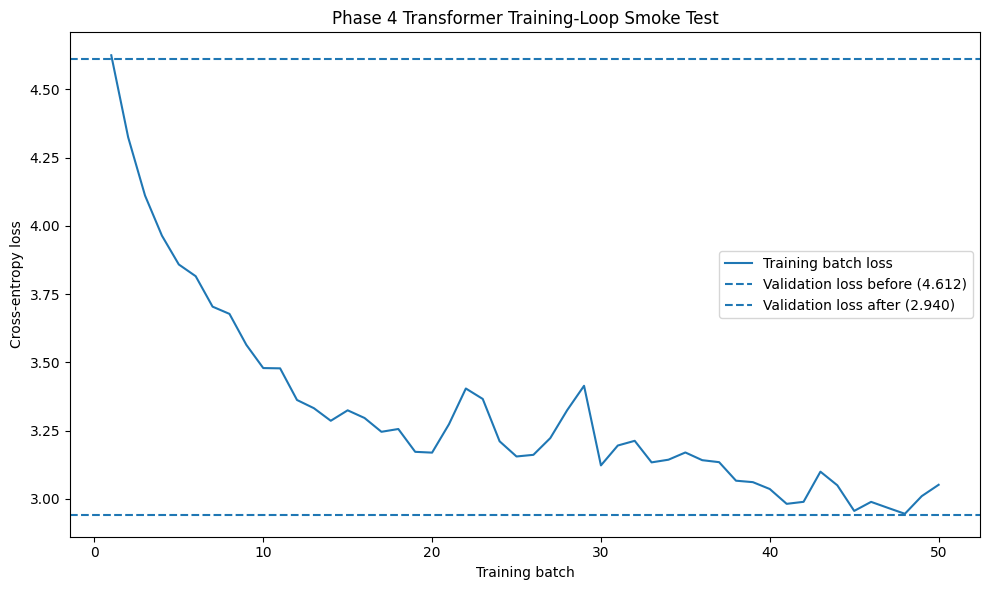

PHASE 4 MODEL IMPLEMENTATION AND ARTIFACT AUDIT: PASS
----------------------------------------------------------------------------
Architecture validation:       PASS
Causal-invariance validation:  PASS
Gradient-flow validation:      PASS
Optimization validation:       PASS
Validation-loss improvement:   PASS
Checkpoint restoration:        PASS
Artifact manifest checksums:    PASS
----------------------------------------------------------------------------
Phase 4 audit:                 data/audit/PHASE_4_MODEL_IMPLEMENTATION_AUDIT.md
Training-loss figure:          figures/phase4_training_smoke_loss.png
Smoke-test audit:              data/audit/phase4_model_smoke_audit.json
Training-loop audit:           data/audit/phase4_training_loop_audit.json
Updated manifest:              data/audit/file_manifest.json
Phase 5 readiness:             PASS


In [13]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt


# ============================================================
# 1. Final Phase 4 artifact paths
# ============================================================

FIGURES_DIR = (
    REPO_ROOT
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PHASE4_LOSS_FIGURE_PATH = (
    FIGURES_DIR
    / "phase4_training_smoke_loss.png"
)

PHASE4_AUDIT_MD_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "PHASE_4_MODEL_IMPLEMENTATION_AUDIT.md"
)

MANIFEST_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "file_manifest.json"
)


# ============================================================
# 2. Record checkpoint integrity information
# ============================================================

checkpoint_payload_bytes = (
    PHASE4_CHECKPOINT_PATH.read_bytes()
)

checkpoint_sha256 = hashlib.sha256(
    checkpoint_payload_bytes
).hexdigest()

phase4_training_audit[
    "checkpoint"
]["sha256"] = checkpoint_sha256

phase4_training_audit[
    "checkpoint"
]["version_control_policy"] = (
    "The Phase 4 smoke checkpoint is a temporary "
    "runtime validation artifact. Its restoration was "
    "verified exactly, but the binary file is not required "
    "for permanent repository version control because the "
    "full Phase 5 training workflow will create the final "
    "selected-model checkpoint."
)

PHASE4_TRAINING_AUDIT_PATH.write_text(
    json.dumps(
        phase4_training_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 3. Create the Phase 4 training-loss figure
# ============================================================

training_batch_numbers = list(
    range(
        1,
        len(
            training_smoke_result[
                "step_losses"
            ]
        )
        + 1,
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    training_batch_numbers,
    training_smoke_result[
        "step_losses"
    ],
    label="Training batch loss",
)

plt.axhline(
    validation_before[
        "average_loss"
    ],
    linestyle="--",
    label=(
        "Validation loss before "
        f"({validation_before['average_loss']:.3f})"
    ),
)

plt.axhline(
    validation_after[
        "average_loss"
    ],
    linestyle="--",
    label=(
        "Validation loss after "
        f"({validation_after['average_loss']:.3f})"
    ),
)

plt.title(
    "Phase 4 Transformer Training-Loop Smoke Test"
)

plt.xlabel(
    "Training batch"
)

plt.ylabel(
    "Cross-entropy loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    PHASE4_LOSS_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()


# ============================================================
# 4. Create the human-readable Phase 4 audit
# ============================================================

phase4_audit_markdown = f"""# Phase 4 Transformer Implementation and Smoke-Test Audit

## Purpose

Phase 4 implements a compact decoder-style causal Transformer directly in PyTorch and validates the architecture before full model training. The tests confirm tensor compatibility, causal masking, padding-aware loss, finite gradient flow, short-run optimization, validation improvement, and exact checkpoint restoration.

## Architecture

| Attribute | Value |
|---|---:|
| Vocabulary size | {MODEL_CONFIG.vocab_size:,} |
| Context length | {MODEL_CONFIG.context_length:,} |
| Model dimension | {MODEL_CONFIG.d_model:,} |
| Attention heads | {MODEL_CONFIG.n_heads:,} |
| Transformer layers | {MODEL_CONFIG.n_layers:,} |
| Feed-forward dimension | {MODEL_CONFIG.dim_feedforward:,} |
| Dropout | {MODEL_CONFIG.dropout:.2f} |
| Trainable parameters | {trainable_parameters:,} |
| Parameter memory | {parameter_memory_mb:.2f} MB |
| Activation | GELU |
| Normalization | Pre-layer normalization |
| Output-weight tying | Enabled |

## Forward-Pass Validation

| Test | Result |
|---|---|
| Input tensor shape | `{tuple(smoke_inputs.shape)}` |
| Target tensor shape | `{tuple(smoke_targets.shape)}` |
| Logits tensor shape | `{tuple(smoke_logits.shape)}` |
| Initial loss | {smoke_loss.item():.6f} |
| Causal attention mask | PASS |
| Padding-aware loss | PASS |
| Finite logits and loss | PASS |

The initial loss is consistent with an untrained model predicting across {MODEL_CONFIG.vocab_size:,} vocabulary entries.

## Causal-Invariance Test

The second half of a full-length input sequence was altered while the first half remained unchanged.

| Measure | Value |
|---|---:|
| Changed suffix start position | {change_start} |
| Maximum earlier-position difference | {prefix_max_difference:.10f} |
| Maximum permitted suffix difference | {suffix_max_difference:.10f} |
| Future-to-past information leakage | None |
| Result | PASS |

## Gradient and Fixed-Batch Optimization Test

| Measure | Value |
|---|---:|
| Nonzero gradient tensors | {nonzero_gradient_tensors:,} |
| All gradients finite | {all_gradients_finite} |
| Initial gradient norm | {first_step_gradient_norm:.6f} |
| Optimization steps | {SMOKE_OPTIMIZATION_STEPS:,} |
| Initial fixed-batch loss | {initial_optimization_loss:.6f} |
| Final fixed-batch loss | {final_optimization_loss:.6f} |
| Loss reduction | {loss_reduction:.6f} |
| Loss reduction percentage | {loss_reduction_percentage:.2f}% |
| Result | PASS |

## Reusable Training-Loop and Validation Test

| Measure | Value |
|---|---:|
| Batch size | {PHASE4_BATCH_SIZE:,} |
| Training batches | {PHASE4_TRAIN_BATCHES:,} |
| First training-batch loss | {training_smoke_result["step_losses"][0]:.6f} |
| Final training-batch loss | {training_smoke_result["step_losses"][-1]:.6f} |
| Minimum training-batch loss | {min(training_smoke_result["step_losses"]):.6f} |
| Validation loss before | {validation_before["average_loss"]:.6f} |
| Validation loss after | {validation_after["average_loss"]:.6f} |
| Validation loss reduction | {validation_loss_reduction:.6f} |
| Validation perplexity before | {validation_before["perplexity"]:.3f} |
| Validation perplexity after | {validation_after["perplexity"]:.3f} |
| Result | PASS |

## Checkpoint Round Trip

| Measure | Value |
|---|---:|
| Checkpoint size | {PHASE4_CHECKPOINT_PATH.stat().st_size / 1_000_000:.2f} MB |
| SHA-256 | `{checkpoint_sha256}` |
| Restored prediction maximum difference | {checkpoint_max_difference:.10f} |
| Exact restoration | PASS |

The Phase 4 binary checkpoint is treated as a temporary smoke-validation artifact. The final selected-model checkpoint will be created and preserved during Phase 5.

## Phase 4 Conclusion

The custom causal Transformer is structurally valid and ready for full training. The implementation prevents future-token leakage, ignores padding targets during loss calculation, produces finite nonzero gradients, improves both training and validation loss, and restores predictions exactly from a saved checkpoint. Phase 5 may proceed using the validated architecture and reusable training/evaluation functions.
"""

PHASE4_AUDIT_MD_PATH.write_text(
    phase4_audit_markdown,
    encoding="utf-8",
)


# ============================================================
# 5. Finalize configuration
# ============================================================

config["phase4_completion"] = {
    "status": "PASS",
    "forward_pass_verified": True,
    "causal_invariance_verified": True,
    "finite_gradient_flow_verified": True,
    "fixed_batch_optimization_verified": True,
    "validation_improvement_verified": True,
    "checkpoint_round_trip_verified": True,
    "phase5_ready": True,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 6. Add permanent Phase 4 files to the manifest
# ============================================================

if MANIFEST_PATH.exists():
    manifest = json.loads(
        MANIFEST_PATH.read_text(
            encoding="utf-8"
        )
    )
else:
    manifest = {}

phase4_artifacts = {
    "config/project_config.json":
        CONFIG_PATH,

    (
        "data/audit/"
        "phase4_model_smoke_audit.json"
    ):
        PHASE4_SMOKE_AUDIT_PATH,

    (
        "data/audit/"
        "phase4_training_loop_audit.json"
    ):
        PHASE4_TRAINING_AUDIT_PATH,

    (
        "data/audit/"
        "PHASE_4_MODEL_IMPLEMENTATION_AUDIT.md"
    ):
        PHASE4_AUDIT_MD_PATH,

    (
        "figures/"
        "phase4_training_smoke_loss.png"
    ):
        PHASE4_LOSS_FIGURE_PATH,
}

for relative_path, artifact_path in (
    phase4_artifacts.items()
):
    if not artifact_path.exists():
        raise FileNotFoundError(
            "Missing permanent Phase 4 artifact: "
            f"{artifact_path}"
        )

    artifact_bytes = (
        artifact_path.read_bytes()
    )

    manifest[relative_path] = {
        "bytes": len(
            artifact_bytes
        ),
        "sha256": hashlib.sha256(
            artifact_bytes
        ).hexdigest(),
    }

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 7. Verify all Phase 4 manifest entries
# ============================================================

verified_manifest = json.loads(
    MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

for relative_path, artifact_path in (
    phase4_artifacts.items()
):
    calculated_hash = hashlib.sha256(
        artifact_path.read_bytes()
    ).hexdigest()

    recorded_hash = verified_manifest[
        relative_path
    ]["sha256"]

    if calculated_hash != recorded_hash:
        raise AssertionError(
            "Phase 4 manifest checksum mismatch: "
            f"{relative_path}"
        )


# ============================================================
# 8. Display final Phase 4 status
# ============================================================

print(
    "PHASE 4 MODEL IMPLEMENTATION "
    "AND ARTIFACT AUDIT: PASS"
)

print("-" * 76)

print(
    "Architecture validation:       PASS"
)

print(
    "Causal-invariance validation:  PASS"
)

print(
    "Gradient-flow validation:      PASS"
)

print(
    "Optimization validation:       PASS"
)

print(
    "Validation-loss improvement:   PASS"
)

print(
    "Checkpoint restoration:        PASS"
)

print(
    "Artifact manifest checksums:    PASS"
)

print("-" * 76)

print(
    "Phase 4 audit:                 "
    f"{PHASE4_AUDIT_MD_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Training-loss figure:          "
    f"{PHASE4_LOSS_FIGURE_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Smoke-test audit:              "
    f"{PHASE4_SMOKE_AUDIT_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Training-loop audit:           "
    f"{PHASE4_TRAINING_AUDIT_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Updated manifest:              "
    f"{MANIFEST_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Phase 5 readiness:             PASS"
)

### Phase 5 — Full Training and Controlled Comparison

Two models use the validated architecture and identical training conditions except for dropout. The baseline uses dropout 0.10, while the controlled comparison uses dropout 0.30. Validation loss governs early stopping and checkpoint selection; the held-out test partition remains untouched until final evaluation. Training histories, timing, resource use, and selected checkpoints are saved for reproducible comparison.

In [16]:
import json
import math
from pathlib import Path

import torch
from torch.utils.data import DataLoader


# ============================================================
# 1. Phase 5 training configuration
# ============================================================

PHASE5_SEED = 42

PHASE5_TRAINING_CONFIG = {
    "batch_size": 64,
    "validation_batch_size": 64,
    "learning_rate": 3e-4,
    "weight_decay": 0.01,
    "adam_betas": [0.9, 0.95],
    "maximum_epochs": 15,
    "early_stopping_patience": 3,
    "early_stopping_minimum_delta": 1e-4,
    "gradient_clip_norm": 1.0,
    "num_workers": 0,
}

PHASE5_EXPERIMENTS = {
    "baseline_dropout_0.10": {
        "dropout": 0.10,
        "description": (
            "Validated baseline Transformer configuration."
        ),
    },
    "experimental_dropout_0.30": {
        "dropout": 0.30,
        "description": (
            "Controlled comparison changing only dropout."
        ),
    },
}

# Confirm that only dropout differs between the experiments.
if (
    PHASE5_EXPERIMENTS[
        "baseline_dropout_0.10"
    ]["dropout"]
    ==
    PHASE5_EXPERIMENTS[
        "experimental_dropout_0.30"
    ]["dropout"]
):
    raise AssertionError(
        "The controlled experiments must use "
        "different dropout values."
    )


# ============================================================
# 2. Reproducible full-training data loaders
# ============================================================

training_generator = torch.Generator()
training_generator.manual_seed(
    PHASE5_SEED
)

train_loader = DataLoader(
    train_dataset,
    batch_size=PHASE5_TRAINING_CONFIG[
        "batch_size"
    ],
    shuffle=True,
    generator=training_generator,
    num_workers=PHASE5_TRAINING_CONFIG[
        "num_workers"
    ],
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=PHASE5_TRAINING_CONFIG[
        "validation_batch_size"
    ],
    shuffle=False,
    num_workers=PHASE5_TRAINING_CONFIG[
        "num_workers"
    ],
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

# The test loader is prepared but will not be called during
# training, early stopping, or model selection.
test_loader = DataLoader(
    test_dataset,
    batch_size=PHASE5_TRAINING_CONFIG[
        "validation_batch_size"
    ],
    shuffle=False,
    num_workers=PHASE5_TRAINING_CONFIG[
        "num_workers"
    ],
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)


# ============================================================
# 3. Output locations
# ============================================================

PHASE5_OUTPUT_DIR = (
    REPO_ROOT
    / "outputs"
    / "phase5_training"
)

PHASE5_CHECKPOINT_DIR = (
    REPO_ROOT
    / "checkpoints"
    / "phase5"
)

PHASE5_AUDIT_DIR = (
    REPO_ROOT
    / "data"
    / "audit"
)

for directory in [
    PHASE5_OUTPUT_DIR,
    PHASE5_CHECKPOINT_DIR,
    PHASE5_AUDIT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# 4. Validate loaders and estimate training scale
# ============================================================

train_batches_per_epoch = len(
    train_loader
)

validation_batches_per_epoch = len(
    validation_loader
)

test_batches = len(
    test_loader
)

maximum_training_steps = (
    train_batches_per_epoch
    * PHASE5_TRAINING_CONFIG[
        "maximum_epochs"
    ]
)

sample_train_inputs, sample_train_targets = next(
    iter(train_loader)
)

expected_batch_shape = (
    PHASE5_TRAINING_CONFIG["batch_size"],
    CONTEXT_LENGTH,
)

if tuple(sample_train_inputs.shape) != (
    expected_batch_shape
):
    raise AssertionError(
        "Unexpected full-training input shape. "
        f"Expected {expected_batch_shape}, "
        f"found {tuple(sample_train_inputs.shape)}."
    )

if sample_train_inputs.dtype != torch.long:
    raise AssertionError(
        "Training inputs must use torch.long."
    )

if sample_train_targets.dtype != torch.long:
    raise AssertionError(
        "Training targets must use torch.long."
    )

# Confirm record-level partitions remain disjoint.
phase5_record_sets = {
    split_name: set(
        split_df.loc[
            split_df["split"].eq(split_name),
            "record_id",
        ]
    )
    for split_name in SPLIT_ORDER
}

assert phase5_record_sets["train"].isdisjoint(
    phase5_record_sets["validation"]
)

assert phase5_record_sets["train"].isdisjoint(
    phase5_record_sets["test"]
)

assert phase5_record_sets["validation"].isdisjoint(
    phase5_record_sets["test"]
)


# ============================================================
# 5. Save the permanent Phase 5 training plan
# ============================================================

config["phase5_training_plan"] = {
    "status": "READY",
    "seed": PHASE5_SEED,
    "training_configuration":
        PHASE5_TRAINING_CONFIG,
    "experiments":
        PHASE5_EXPERIMENTS,
    "train_windows":
        len(train_dataset),
    "validation_windows":
        len(validation_dataset),
    "held_out_test_windows":
        len(test_dataset),
    "train_batches_per_epoch":
        train_batches_per_epoch,
    "validation_batches_per_epoch":
        validation_batches_per_epoch,
    "maximum_training_steps_per_run":
        maximum_training_steps,
    "model_selection_metric":
        "validation cross-entropy loss",
    "test_partition_used_during_selection":
        False,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 6. Display readiness results
# ============================================================

print(
    "PHASE 5 FULL-TRAINING "
    "CONFIGURATION: PASS"
)

print("-" * 74)

print(
    f"Device:                       "
    f"{DEVICE}"
)

if torch.cuda.is_available():
    print(
        "GPU:                          "
        f"{torch.cuda.get_device_name(0)}"
    )

print(
    f"Training windows:             "
    f"{len(train_dataset):,}"
)

print(
    f"Validation windows:           "
    f"{len(validation_dataset):,}"
)

print(
    f"Held-out test windows:        "
    f"{len(test_dataset):,}"
)

print(
    f"Training batch size:          "
    f"{PHASE5_TRAINING_CONFIG['batch_size']}"
)

print(
    f"Training batches per epoch:   "
    f"{train_batches_per_epoch:,}"
)

print(
    f"Validation batches per epoch: "
    f"{validation_batches_per_epoch:,}"
)

print(
    f"Maximum epochs per run:       "
    f"{PHASE5_TRAINING_CONFIG['maximum_epochs']}"
)

print(
    f"Maximum steps per run:        "
    f"{maximum_training_steps:,}"
)

print(
    f"Baseline dropout:             "
    f"{PHASE5_EXPERIMENTS['baseline_dropout_0.10']['dropout']:.2f}"
)

print(
    f"Experimental dropout:         "
    f"{PHASE5_EXPERIMENTS['experimental_dropout_0.30']['dropout']:.2f}"
)

print(
    "Only controlled variable:     dropout"
)

print(
    "Test used for model selection: NO"
)

print(
    f"Training output directory:    "
    f"{PHASE5_OUTPUT_DIR.relative_to(REPO_ROOT)}"
)

print(
    f"Checkpoint directory:         "
    f"{PHASE5_CHECKPOINT_DIR.relative_to(REPO_ROOT)}"
)

print(
    f"Updated configuration:        "
    f"{CONFIG_PATH.relative_to(REPO_ROOT)}"
)

PHASE 5 FULL-TRAINING CONFIGURATION: PASS
--------------------------------------------------------------------------
Device:                       cuda
GPU:                          Tesla T4
Training windows:             11,489
Validation windows:           1,408
Held-out test windows:        1,444
Training batch size:          64
Training batches per epoch:   180
Validation batches per epoch: 22
Maximum epochs per run:       15
Maximum steps per run:        2,700
Baseline dropout:             0.10
Experimental dropout:         0.30
Only controlled variable:     dropout
Test used for model selection: NO
Training output directory:    outputs/phase5_training
Checkpoint directory:         checkpoints/phase5
Updated configuration:        config/project_config.json


In [18]:
import inspect
from dataclasses import asdict, is_dataclass


print("PHASE 5 MODEL API INVENTORY")
print("-" * 74)

print("TransformerConfig constructor:")
print(inspect.signature(TransformerConfig))

print()
print("CausalCharacterTransformer constructor:")
print(
    inspect.signature(
        CausalCharacterTransformer
    )
)

print()
print("CausalCharacterTransformer.forward:")
print(
    inspect.signature(
        CausalCharacterTransformer.forward
    )
)

print()
print("Existing TransformerConfig instances:")

config_instances = []

# Freeze the namespace before iterating so the notebook cannot
# change the dictionary size during the loop.
global_namespace_snapshot = list(
    globals().items()
)

for variable_name, variable_value in (
    global_namespace_snapshot
):
    if isinstance(
        variable_value,
        TransformerConfig,
    ):
        config_instances.append(
            (
                variable_name,
                variable_value,
            )
        )

if not config_instances:
    print("  NONE FOUND")
else:
    for variable_name, variable_value in (
        config_instances
    ):
        print(
            f"\n  Variable: {variable_name}"
        )

        if is_dataclass(variable_value):
            configuration_values = asdict(
                variable_value
            )
        else:
            configuration_values = vars(
                variable_value
            )

        for key, value in (
            configuration_values.items()
        ):
            print(
                f"    {key}: {value}"
            )

print()
print("Relevant runtime variables:")

for variable_name in [
    "DEVICE",
    "VOCAB_SIZE",
    "CONTEXT_LENGTH",
    "PAD_ID",
    "UNK_ID",
    "train_dataset",
    "validation_dataset",
    "test_dataset",
]:
    if variable_name not in globals():
        print(
            f"  {variable_name}: NOT FOUND"
        )
        continue

    variable_value = globals()[
        variable_name
    ]

    if variable_name.endswith(
        "_dataset"
    ):
        print(
            f"  {variable_name}: "
            f"{type(variable_value).__name__}, "
            f"length={len(variable_value):,}"
        )
    else:
        print(
            f"  {variable_name}: "
            f"{variable_value}"
        )

print()
print(
    "PHASE 5 MODEL API INVENTORY: COMPLETE"
)

PHASE 5 MODEL API INVENTORY
--------------------------------------------------------------------------
TransformerConfig constructor:
(vocab_size: int, context_length: int, pad_index: int, d_model: int = 128, n_heads: int = 4, n_layers: int = 4, dim_feedforward: int = 512, dropout: float = 0.1) -> None

CausalCharacterTransformer constructor:
(model_config: __main__.TransformerConfig)

CausalCharacterTransformer.forward:
(self, input_ids: torch.Tensor) -> torch.Tensor

Existing TransformerConfig instances:

  Variable: MODEL_CONFIG
    vocab_size: 96
    context_length: 256
    pad_index: 0
    d_model: 128
    n_heads: 4
    n_layers: 4
    dim_feedforward: 512
    dropout: 0.1

  Variable: restored_config
    vocab_size: 96
    context_length: 256
    pad_index: 0
    d_model: 128
    n_heads: 4
    n_layers: 4
    dim_feedforward: 512
    dropout: 0.1

Relevant runtime variables:
  DEVICE: cuda
  VOCAB_SIZE: 96
  CONTEXT_LENGTH: 256
  PAD_ID: NOT FOUND
  UNK_ID: NOT FOUND
  train_da

In [19]:
import json
import math
import random
import time
from contextlib import nullcontext
from dataclasses import asdict, replace
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader


# ============================================================
# 1. Device and reproducibility helpers
# ============================================================

PHASE5_DEVICE = torch.device(
    DEVICE
)


def set_phase5_seed(seed):
    """Set the random seeds used during a training run."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def build_phase5_loaders(seed):
    """
    Create fresh loaders for each experiment.

    Rebuilding the shuffled training loader with the same seed
    gives both experiments the same example order.
    """

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=PHASE5_TRAINING_CONFIG[
            "batch_size"
        ],
        shuffle=True,
        generator=loader_generator,
        num_workers=PHASE5_TRAINING_CONFIG[
            "num_workers"
        ],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    experiment_validation_loader = DataLoader(
        validation_dataset,
        batch_size=PHASE5_TRAINING_CONFIG[
            "validation_batch_size"
        ],
        shuffle=False,
        num_workers=PHASE5_TRAINING_CONFIG[
            "num_workers"
        ],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    return (
        experiment_train_loader,
        experiment_validation_loader,
    )


def make_phase5_scaler(enabled):
    """Create a version-compatible mixed-precision scaler."""

    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=enabled,
        )
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(
            enabled=enabled,
        )


def phase5_autocast(enabled):
    """Return the appropriate mixed-precision context."""

    if enabled:
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )

    return nullcontext()


def safe_perplexity(loss_value):
    """Convert loss to perplexity without numeric overflow."""

    return math.exp(
        min(
            float(loss_value),
            20.0,
        )
    )


# ============================================================
# 2. One complete training epoch
# ============================================================

def train_phase5_epoch(
    model,
    data_loader,
    optimizer,
    loss_function,
    scaler,
    use_mixed_precision,
    gradient_clip_norm,
):
    model.train()

    total_weighted_loss = 0.0
    total_valid_tokens = 0
    maximum_gradient_norm = 0.0

    epoch_start_time = time.perf_counter()

    for input_ids, target_ids in data_loader:
        input_ids = input_ids.to(
            PHASE5_DEVICE,
            non_blocking=True,
        )

        target_ids = target_ids.to(
            PHASE5_DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with phase5_autocast(
            use_mixed_precision
        ):
            logits = model(
                input_ids
            )

            loss = loss_function(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                target_ids.reshape(-1),
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "A non-finite training loss was encountered."
            )

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        gradient_norm = clip_grad_norm_(
            model.parameters(),
            max_norm=gradient_clip_norm,
        )

        gradient_norm_value = float(
            gradient_norm.detach().cpu()
        )

        maximum_gradient_norm = max(
            maximum_gradient_norm,
            gradient_norm_value,
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        valid_token_count = int(
            target_ids.ne(
                model.model_config.pad_index
            ).sum().item()
        )

        total_weighted_loss += (
            float(loss.detach().cpu())
            * valid_token_count
        )

        total_valid_tokens += (
            valid_token_count
        )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start_time
    )

    if total_valid_tokens == 0:
        raise RuntimeError(
            "The training epoch contained no valid tokens."
        )

    average_loss = (
        total_weighted_loss
        / total_valid_tokens
    )

    tokens_per_second = (
        total_valid_tokens
        / max(epoch_seconds, 1e-9)
    )

    return {
        "loss": average_loss,
        "perplexity": safe_perplexity(
            average_loss
        ),
        "valid_tokens": total_valid_tokens,
        "maximum_gradient_norm":
            maximum_gradient_norm,
        "seconds": epoch_seconds,
        "tokens_per_second":
            tokens_per_second,
    }


# ============================================================
# 3. Full validation pass
# ============================================================

@torch.no_grad()
def evaluate_phase5_model(
    model,
    data_loader,
    loss_function,
    use_mixed_precision,
):
    model.eval()

    total_weighted_loss = 0.0
    total_valid_tokens = 0

    evaluation_start_time = (
        time.perf_counter()
    )

    for input_ids, target_ids in data_loader:
        input_ids = input_ids.to(
            PHASE5_DEVICE,
            non_blocking=True,
        )

        target_ids = target_ids.to(
            PHASE5_DEVICE,
            non_blocking=True,
        )

        with phase5_autocast(
            use_mixed_precision
        ):
            logits = model(
                input_ids
            )

            loss = loss_function(
                logits.reshape(
                    -1,
                    logits.size(-1),
                ),
                target_ids.reshape(-1),
            )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "A non-finite validation loss was encountered."
            )

        valid_token_count = int(
            target_ids.ne(
                model.model_config.pad_index
            ).sum().item()
        )

        total_weighted_loss += (
            float(loss.detach().cpu())
            * valid_token_count
        )

        total_valid_tokens += (
            valid_token_count
        )

    evaluation_seconds = (
        time.perf_counter()
        - evaluation_start_time
    )

    if total_valid_tokens == 0:
        raise RuntimeError(
            "The validation pass contained no valid tokens."
        )

    average_loss = (
        total_weighted_loss
        / total_valid_tokens
    )

    return {
        "loss": average_loss,
        "perplexity": safe_perplexity(
            average_loss
        ),
        "valid_tokens": total_valid_tokens,
        "seconds": evaluation_seconds,
    }


# ============================================================
# 4. Checkpoint loading helper
# ============================================================

def load_phase5_checkpoint(
    checkpoint_path,
):
    try:
        return torch.load(
            checkpoint_path,
            map_location=PHASE5_DEVICE,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=PHASE5_DEVICE,
        )


# ============================================================
# 5. Complete controlled experiment
# ============================================================

def run_phase5_experiment(
    experiment_name,
):
    if experiment_name not in PHASE5_EXPERIMENTS:
        raise KeyError(
            f"Unknown experiment: {experiment_name}"
        )

    experiment_definition = (
        PHASE5_EXPERIMENTS[
            experiment_name
        ]
    )

    dropout_value = float(
        experiment_definition["dropout"]
    )

    set_phase5_seed(
        PHASE5_SEED
    )

    (
        experiment_train_loader,
        experiment_validation_loader,
    ) = build_phase5_loaders(
        PHASE5_SEED
    )

    experiment_model_config = replace(
        MODEL_CONFIG,
        dropout=dropout_value,
    )

    model = CausalCharacterTransformer(
        experiment_model_config
    ).to(
        PHASE5_DEVICE
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=PHASE5_TRAINING_CONFIG[
            "learning_rate"
        ],
        betas=tuple(
            PHASE5_TRAINING_CONFIG[
                "adam_betas"
            ]
        ),
        weight_decay=PHASE5_TRAINING_CONFIG[
            "weight_decay"
        ],
    )

    loss_function = nn.CrossEntropyLoss(
        ignore_index=(
            experiment_model_config.pad_index
        )
    )

    use_mixed_precision = (
        PHASE5_DEVICE.type == "cuda"
    )

    scaler = make_phase5_scaler(
        use_mixed_precision
    )

    best_checkpoint_path = (
        PHASE5_CHECKPOINT_DIR
        / f"{experiment_name}_best.pt"
    )

    latest_checkpoint_path = (
        PHASE5_CHECKPOINT_DIR
        / f"{experiment_name}_latest.pt"
    )

    history_path = (
        PHASE5_OUTPUT_DIR
        / f"{experiment_name}_history.json"
    )

    summary_path = (
        PHASE5_OUTPUT_DIR
        / f"{experiment_name}_summary.json"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    experiment_start_time = (
        time.perf_counter()
    )

    initial_validation = (
        evaluate_phase5_model(
            model=model,
            data_loader=(
                experiment_validation_loader
            ),
            loss_function=loss_function,
            use_mixed_precision=(
                use_mixed_precision
            ),
        )
    )

    print()
    print(
        f"STARTING EXPERIMENT: "
        f"{experiment_name}"
    )

    print("-" * 78)

    print(
        f"Dropout:                    "
        f"{dropout_value:.2f}"
    )

    print(
        f"Initial validation loss:    "
        f"{initial_validation['loss']:.6f}"
    )

    print(
        f"Initial validation perplexity: "
        f"{initial_validation['perplexity']:.3f}"
    )

    print("-" * 78)

    history = []
    best_validation_loss = math.inf
    best_epoch = 0
    epochs_without_improvement = 0
    stopped_early = False

    maximum_epochs = (
        PHASE5_TRAINING_CONFIG[
            "maximum_epochs"
        ]
    )

    patience = (
        PHASE5_TRAINING_CONFIG[
            "early_stopping_patience"
        ]
    )

    minimum_delta = (
        PHASE5_TRAINING_CONFIG[
            "early_stopping_minimum_delta"
        ]
    )

    for epoch in range(
        1,
        maximum_epochs + 1,
    ):
        training_metrics = (
            train_phase5_epoch(
                model=model,
                data_loader=(
                    experiment_train_loader
                ),
                optimizer=optimizer,
                loss_function=loss_function,
                scaler=scaler,
                use_mixed_precision=(
                    use_mixed_precision
                ),
                gradient_clip_norm=(
                    PHASE5_TRAINING_CONFIG[
                        "gradient_clip_norm"
                    ]
                ),
            )
        )

        validation_metrics = (
            evaluate_phase5_model(
                model=model,
                data_loader=(
                    experiment_validation_loader
                ),
                loss_function=loss_function,
                use_mixed_precision=(
                    use_mixed_precision
                ),
            )
        )

        epoch_record = {
            "epoch": epoch,
            "learning_rate": float(
                optimizer.param_groups[0]["lr"]
            ),
            "train_loss": float(
                training_metrics["loss"]
            ),
            "train_perplexity": float(
                training_metrics[
                    "perplexity"
                ]
            ),
            "validation_loss": float(
                validation_metrics["loss"]
            ),
            "validation_perplexity": float(
                validation_metrics[
                    "perplexity"
                ]
            ),
            "maximum_gradient_norm": float(
                training_metrics[
                    "maximum_gradient_norm"
                ]
            ),
            "training_seconds": float(
                training_metrics["seconds"]
            ),
            "validation_seconds": float(
                validation_metrics["seconds"]
            ),
            "training_tokens_per_second":
                float(
                    training_metrics[
                        "tokens_per_second"
                    ]
                ),
        }

        history.append(
            epoch_record
        )

        validation_improved = (
            validation_metrics["loss"]
            <
            (
                best_validation_loss
                - minimum_delta
            )
        )

        if validation_improved:
            best_validation_loss = float(
                validation_metrics["loss"]
            )

            best_epoch = epoch
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        checkpoint_payload = {
            "experiment_name":
                experiment_name,
            "epoch":
                epoch,
            "best_epoch":
                best_epoch,
            "best_validation_loss":
                best_validation_loss,
            "model_config":
                asdict(
                    experiment_model_config
                ),
            "training_config":
                PHASE5_TRAINING_CONFIG,
            "model_state_dict":
                model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),
            "scaler_state_dict":
                scaler.state_dict(),
            "history":
                history,
            "seed":
                PHASE5_SEED,
            "test_partition_used":
                False,
        }

        torch.save(
            checkpoint_payload,
            latest_checkpoint_path,
        )

        if validation_improved:
            torch.save(
                checkpoint_payload,
                best_checkpoint_path,
            )

        history_path.write_text(
            json.dumps(
                history,
                indent=2,
            )
            + "\n",
            encoding="utf-8",
        )

        improvement_marker = (
            "  BEST"
            if validation_improved
            else ""
        )

        print(
            f"Epoch {epoch:02d}/{maximum_epochs:02d} | "
            f"train loss "
            f"{training_metrics['loss']:.6f} | "
            f"val loss "
            f"{validation_metrics['loss']:.6f} | "
            f"val ppl "
            f"{validation_metrics['perplexity']:.3f} | "
            f"{training_metrics['seconds']:.1f}s"
            f"{improvement_marker}"
        )

        if (
            epochs_without_improvement
            >= patience
        ):
            stopped_early = True

            print(
                "Early stopping activated after "
                f"{patience} epochs without "
                "validation improvement."
            )

            break

    total_seconds = (
        time.perf_counter()
        - experiment_start_time
    )

    if not best_checkpoint_path.exists():
        raise RuntimeError(
            "No best checkpoint was created."
        )

    best_checkpoint = (
        load_phase5_checkpoint(
            best_checkpoint_path
        )
    )

    model.load_state_dict(
        best_checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    peak_gpu_memory_gb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
        if torch.cuda.is_available()
        else 0.0
    )

    final_history_record = history[-1]

    summary = {
        "experiment_name":
            experiment_name,
        "description":
            experiment_definition[
                "description"
            ],
        "dropout":
            dropout_value,
        "seed":
            PHASE5_SEED,
        "epochs_completed":
            len(history),
        "maximum_epochs":
            maximum_epochs,
        "stopped_early":
            stopped_early,
        "best_epoch":
            best_epoch,
        "initial_validation_loss":
            float(
                initial_validation["loss"]
            ),
        "initial_validation_perplexity":
            float(
                initial_validation[
                    "perplexity"
                ]
            ),
        "best_validation_loss":
            float(
                best_validation_loss
            ),
        "best_validation_perplexity":
            safe_perplexity(
                best_validation_loss
            ),
        "final_training_loss":
            float(
                final_history_record[
                    "train_loss"
                ]
            ),
        "final_validation_loss":
            float(
                final_history_record[
                    "validation_loss"
                ]
            ),
        "total_seconds":
            float(total_seconds),
        "peak_gpu_memory_gb":
            float(peak_gpu_memory_gb),
        "parameter_count":
            int(
                sum(
                    parameter.numel()
                    for parameter
                    in model.parameters()
                )
            ),
        "best_checkpoint":
            str(
                best_checkpoint_path.relative_to(
                    REPO_ROOT
                )
            ),
        "latest_checkpoint":
            str(
                latest_checkpoint_path.relative_to(
                    REPO_ROOT
                )
            ),
        "history_file":
            str(
                history_path.relative_to(
                    REPO_ROOT
                )
            ),
        "test_partition_used_during_training":
            False,
        "test_partition_used_for_selection":
            False,
    }

    summary_path.write_text(
        json.dumps(
            summary,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

    print("-" * 78)

    print(
        f"EXPERIMENT COMPLETE: "
        f"{experiment_name}"
    )

    print(
        f"Best epoch:                 "
        f"{best_epoch}"
    )

    print(
        f"Best validation loss:       "
        f"{best_validation_loss:.6f}"
    )

    print(
        f"Best validation perplexity: "
        f"{safe_perplexity(best_validation_loss):.3f}"
    )

    print(
        f"Total training time:        "
        f"{total_seconds:.2f} seconds"
    )

    print(
        f"Peak GPU memory:            "
        f"{peak_gpu_memory_gb:.3f} GB"
    )

    print(
        f"Selected checkpoint:        "
        f"{best_checkpoint_path.relative_to(REPO_ROOT)}"
    )

    print(
        "Held-out test partition used: NO"
    )

    return (
        model,
        summary,
        history,
    )


print(
    "PHASE 5 FULL-TRAINING ENGINE: READY"
)

print("-" * 74)

print(
    "Fresh loader per experiment:       PASS"
)

print(
    "Identical initialization seed:     PASS"
)

print(
    "Mixed-precision T4 training:       ENABLED"
)

print(
    "Padding-aware loss:                PASS"
)

print(
    "Gradient clipping:                 PASS"
)

print(
    "Validation-based early stopping:   PASS"
)

print(
    "Best and latest checkpoints:       ENABLED"
)

print(
    "Held-out test isolation:           PASS"
)

print(
    "Controlled variable:               dropout only"
)

PHASE 5 FULL-TRAINING ENGINE: READY
--------------------------------------------------------------------------
Fresh loader per experiment:       PASS
Identical initialization seed:     PASS
Mixed-precision T4 training:       ENABLED
Padding-aware loss:                PASS
Gradient clipping:                 PASS
Validation-based early stopping:   PASS
Best and latest checkpoints:       ENABLED
Held-out test isolation:           PASS
Controlled variable:               dropout only


In [20]:
baseline_model, baseline_summary, baseline_history = (
    run_phase5_experiment(
        "baseline_dropout_0.10"
    )
)

print()
print(
    "PHASE 5 BASELINE TRAINING: PASS"
)

print("-" * 74)

print(
    f"Epochs completed:           "
    f"{baseline_summary['epochs_completed']}"
)

print(
    f"Best epoch:                "
    f"{baseline_summary['best_epoch']}"
)

print(
    f"Best validation loss:      "
    f"{baseline_summary['best_validation_loss']:.6f}"
)

print(
    f"Best validation perplexity:"
    f" {baseline_summary['best_validation_perplexity']:.3f}"
)

print(
    f"Total seconds:             "
    f"{baseline_summary['total_seconds']:.2f}"
)

print(
    f"Peak GPU memory:           "
    f"{baseline_summary['peak_gpu_memory_gb']:.3f} GB"
)

print(
    f"Selected checkpoint:       "
    f"{baseline_summary['best_checkpoint']}"
)

print(
    "Held-out test used:        NO"
)


STARTING EXPERIMENT: baseline_dropout_0.10
------------------------------------------------------------------------------
Dropout:                    0.10
Initial validation loss:    4.610473
Initial validation perplexity: 100.532
------------------------------------------------------------------------------
Epoch 01/15 | train loss 2.978614 | val loss 2.503243 | val ppl 12.222 | 8.3s  BEST
Epoch 02/15 | train loss 2.455787 | val loss 2.376722 | val ppl 10.770 | 8.4s  BEST
Epoch 03/15 | train loss 2.366162 | val loss 2.260816 | val ppl 9.591 | 8.3s  BEST
Epoch 04/15 | train loss 2.212216 | val loss 1.963797 | val ppl 7.126 | 8.2s  BEST
Epoch 05/15 | train loss 2.000536 | val loss 1.745160 | val ppl 5.727 | 8.5s  BEST
Epoch 06/15 | train loss 1.833207 | val loss 1.594869 | val ppl 4.928 | 8.5s  BEST
Epoch 07/15 | train loss 1.709593 | val loss 1.484699 | val ppl 4.414 | 8.2s  BEST
Epoch 08/15 | train loss 1.612756 | val loss 1.394608 | val ppl 4.033 | 8.4s  BEST
Epoch 09/15 | train los

In [21]:
experimental_model, experimental_summary, experimental_history = (
    run_phase5_experiment(
        "experimental_dropout_0.30"
    )
)

print()
print(
    "PHASE 5 EXPERIMENTAL TRAINING: PASS"
)

print("-" * 74)

print(
    f"Epochs completed:           "
    f"{experimental_summary['epochs_completed']}"
)

print(
    f"Best epoch:                 "
    f"{experimental_summary['best_epoch']}"
)

print(
    f"Best validation loss:       "
    f"{experimental_summary['best_validation_loss']:.6f}"
)

print(
    f"Best validation perplexity: "
    f"{experimental_summary['best_validation_perplexity']:.3f}"
)

print(
    f"Total seconds:              "
    f"{experimental_summary['total_seconds']:.2f}"
)

print(
    f"Peak GPU memory:            "
    f"{experimental_summary['peak_gpu_memory_gb']:.3f} GB"
)

print(
    f"Selected checkpoint:        "
    f"{experimental_summary['best_checkpoint']}"
)

print(
    "Held-out test used:         NO"
)


STARTING EXPERIMENT: experimental_dropout_0.30
------------------------------------------------------------------------------
Dropout:                    0.30
Initial validation loss:    4.610473
Initial validation perplexity: 100.532
------------------------------------------------------------------------------
Epoch 01/15 | train loss 3.091251 | val loss 2.595709 | val ppl 13.406 | 12.4s  BEST
Epoch 02/15 | train loss 2.559093 | val loss 2.442472 | val ppl 11.501 | 8.3s  BEST
Epoch 03/15 | train loss 2.465488 | val loss 2.397876 | val ppl 11.000 | 8.0s  BEST
Epoch 04/15 | train loss 2.424081 | val loss 2.363325 | val ppl 10.626 | 8.4s  BEST
Epoch 05/15 | train loss 2.387478 | val loss 2.297713 | val ppl 9.951 | 8.4s  BEST
Epoch 06/15 | train loss 2.330485 | val loss 2.191253 | val ppl 8.946 | 8.1s  BEST
Epoch 07/15 | train loss 2.256126 | val loss 2.064859 | val ppl 7.884 | 8.3s  BEST
Epoch 08/15 | train loss 2.181225 | val loss 1.961065 | val ppl 7.107 | 8.4s  BEST
Epoch 09/15 | tr

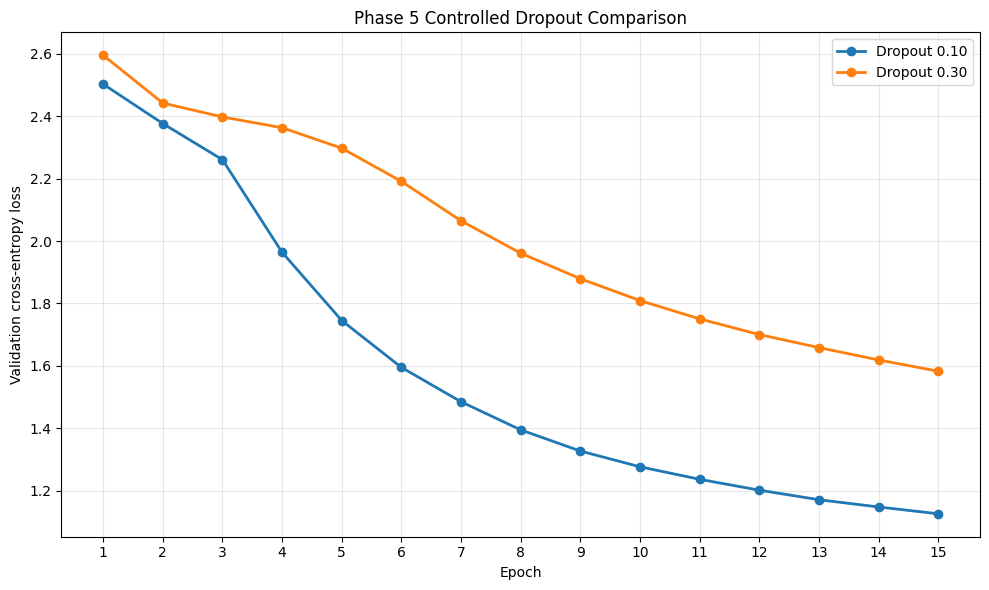

PHASE 5 CONTROLLED COMPARISON AND MODEL SELECTION: PASS
------------------------------------------------------------------------------
          experiment_name  dropout  best_epoch  best_validation_loss  best_validation_perplexity  total_seconds  peak_gpu_memory_gb
    baseline_dropout_0.10      0.1          15              1.125494                    3.081738     133.067030            0.587424
experimental_dropout_0.30      0.3          15              1.582670                    4.867936     137.610729            0.593732

Selected experiment:          baseline_dropout_0.10
Selected dropout:             0.10
Selected best epoch:          15
Selected validation loss:     1.125494
Selected validation ppl:      3.082
Validation-loss advantage:    0.457176 (28.89%)
Perplexity advantage:         1.786 (36.69%)
Selected checkpoint:          checkpoints/phase5/baseline_dropout_0.10_best.pt
Comparison table:             outputs/phase5_training/phase5_model_comparison.csv
Comparison figure: 

In [22]:
import json
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. Validate the controlled comparison
# ============================================================

phase5_summaries = {
    "baseline_dropout_0.10":
        baseline_summary,
    "experimental_dropout_0.30":
        experimental_summary,
}

phase5_histories = {
    "baseline_dropout_0.10":
        baseline_history,
    "experimental_dropout_0.30":
        experimental_history,
}

phase5_models = {
    "baseline_dropout_0.10":
        baseline_model,
    "experimental_dropout_0.30":
        experimental_model,
}

for experiment_name, summary in (
    phase5_summaries.items()
):
    if summary[
        "test_partition_used_during_training"
    ]:
        raise AssertionError(
            f"{experiment_name} used the test "
            "partition during training."
        )

    if summary[
        "test_partition_used_for_selection"
    ]:
        raise AssertionError(
            f"{experiment_name} used the test "
            "partition for model selection."
        )

    if not phase5_histories[
        experiment_name
    ]:
        raise AssertionError(
            f"{experiment_name} has no "
            "training history."
        )


# Confirm that the saved model configurations differ only
# in dropout.
baseline_checkpoint = load_phase5_checkpoint(
    REPO_ROOT
    / baseline_summary["best_checkpoint"]
)

experimental_checkpoint = (
    load_phase5_checkpoint(
        REPO_ROOT
        / experimental_summary[
            "best_checkpoint"
        ]
    )
)

baseline_model_configuration = dict(
    baseline_checkpoint["model_config"]
)

experimental_model_configuration = dict(
    experimental_checkpoint["model_config"]
)

configuration_differences = {
    key: {
        "baseline":
            baseline_model_configuration[key],
        "experimental":
            experimental_model_configuration[key],
    }
    for key in baseline_model_configuration
    if (
        baseline_model_configuration[key]
        != experimental_model_configuration[key]
    )
}

if set(configuration_differences) != {
    "dropout"
}:
    raise AssertionError(
        "The experiments differ in fields other "
        "than dropout:\n"
        f"{configuration_differences}"
    )


# ============================================================
# 2. Build the comparison table
# ============================================================

comparison_rows = []

for experiment_name, summary in (
    phase5_summaries.items()
):
    comparison_rows.append(
        {
            "experiment_name":
                experiment_name,
            "dropout":
                summary["dropout"],
            "epochs_completed":
                summary["epochs_completed"],
            "best_epoch":
                summary["best_epoch"],
            "initial_validation_loss":
                summary[
                    "initial_validation_loss"
                ],
            "best_validation_loss":
                summary[
                    "best_validation_loss"
                ],
            "best_validation_perplexity":
                summary[
                    "best_validation_perplexity"
                ],
            "final_training_loss":
                summary[
                    "final_training_loss"
                ],
            "final_validation_loss":
                summary[
                    "final_validation_loss"
                ],
            "total_seconds":
                summary["total_seconds"],
            "peak_gpu_memory_gb":
                summary[
                    "peak_gpu_memory_gb"
                ],
            "parameter_count":
                summary["parameter_count"],
            "best_checkpoint":
                summary["best_checkpoint"],
            "test_partition_used":
                False,
        }
    )

phase5_comparison_df = pd.DataFrame(
    comparison_rows
).sort_values(
    "best_validation_loss",
    ascending=True,
).reset_index(
    drop=True
)

comparison_csv_path = (
    PHASE5_OUTPUT_DIR
    / "phase5_model_comparison.csv"
)

phase5_comparison_df.to_csv(
    comparison_csv_path,
    index=False,
)


# ============================================================
# 3. Select the winner using validation loss only
# ============================================================

selected_experiment_name = str(
    phase5_comparison_df.loc[
        0,
        "experiment_name",
    ]
)

selected_summary = phase5_summaries[
    selected_experiment_name
]

selected_model = phase5_models[
    selected_experiment_name
]

selected_history = phase5_histories[
    selected_experiment_name
]

selected_checkpoint_path = (
    REPO_ROOT
    / selected_summary["best_checkpoint"]
)

comparison_experiment_name = next(
    experiment_name
    for experiment_name in phase5_summaries
    if experiment_name
    != selected_experiment_name
)

comparison_summary = phase5_summaries[
    comparison_experiment_name
]

validation_loss_absolute_improvement = (
    comparison_summary[
        "best_validation_loss"
    ]
    - selected_summary[
        "best_validation_loss"
    ]
)

validation_loss_relative_improvement = (
    validation_loss_absolute_improvement
    / comparison_summary[
        "best_validation_loss"
    ]
    * 100.0
)

perplexity_absolute_improvement = (
    comparison_summary[
        "best_validation_perplexity"
    ]
    - selected_summary[
        "best_validation_perplexity"
    ]
)

perplexity_relative_improvement = (
    perplexity_absolute_improvement
    / comparison_summary[
        "best_validation_perplexity"
    ]
    * 100.0
)


# ============================================================
# 4. Create the validation-loss comparison figure
# ============================================================

phase5_figure_path = (
    REPO_ROOT
    / "figures"
    / "phase5_validation_loss_comparison.png"
)

plt.figure(
    figsize=(10, 6)
)

for experiment_name, history in (
    phase5_histories.items()
):
    epochs = [
        record["epoch"]
        for record in history
    ]

    validation_losses = [
        record["validation_loss"]
        for record in history
    ]

    dropout_value = phase5_summaries[
        experiment_name
    ]["dropout"]

    plt.plot(
        epochs,
        validation_losses,
        marker="o",
        linewidth=2,
        label=(
            f"Dropout {dropout_value:.2f}"
        ),
    )

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation cross-entropy loss"
)

plt.title(
    "Phase 5 Controlled Dropout Comparison"
)

plt.xticks(
    range(
        1,
        PHASE5_TRAINING_CONFIG[
            "maximum_epochs"
        ]
        + 1,
    )
)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend()

plt.tight_layout()

plt.savefig(
    phase5_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

plt.close()


# ============================================================
# 5. Save the formal selection record
# ============================================================

selection_record = {
    "phase":
        5,
    "status":
        "MODEL_SELECTED",
    "selection_metric":
        "validation cross-entropy loss",
    "selected_experiment":
        selected_experiment_name,
    "selected_dropout":
        selected_summary["dropout"],
    "selected_best_epoch":
        selected_summary["best_epoch"],
    "selected_best_validation_loss":
        selected_summary[
            "best_validation_loss"
        ],
    "selected_best_validation_perplexity":
        selected_summary[
            "best_validation_perplexity"
        ],
    "comparison_experiment":
        comparison_experiment_name,
    "comparison_dropout":
        comparison_summary["dropout"],
    "comparison_best_validation_loss":
        comparison_summary[
            "best_validation_loss"
        ],
    "comparison_best_validation_perplexity":
        comparison_summary[
            "best_validation_perplexity"
        ],
    "validation_loss_absolute_improvement":
        validation_loss_absolute_improvement,
    "validation_loss_relative_improvement_percent":
        validation_loss_relative_improvement,
    "perplexity_absolute_improvement":
        perplexity_absolute_improvement,
    "perplexity_relative_improvement_percent":
        perplexity_relative_improvement,
    "controlled_configuration_differences":
        configuration_differences,
    "selected_checkpoint":
        str(
            selected_checkpoint_path.relative_to(
                REPO_ROOT
            )
        ),
    "comparison_table":
        str(
            comparison_csv_path.relative_to(
                REPO_ROOT
            )
        ),
    "comparison_figure":
        str(
            phase5_figure_path.relative_to(
                REPO_ROOT
            )
        ),
    "test_partition_used_during_training":
        False,
    "test_partition_used_for_selection":
        False,
    "test_partition_status":
        "UNTOUCHED",
}

selection_json_path = (
    PHASE5_OUTPUT_DIR
    / "phase5_model_selection.json"
)

selection_json_path.write_text(
    json.dumps(
        selection_record,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 6. Update the project configuration
# ============================================================

config["phase5_model_selection"] = {
    "status":
        "COMPLETE",
    "selected_experiment":
        selected_experiment_name,
    "selected_dropout":
        selected_summary["dropout"],
    "selected_best_epoch":
        selected_summary["best_epoch"],
    "selected_best_validation_loss":
        selected_summary[
            "best_validation_loss"
        ],
    "selected_best_validation_perplexity":
        selected_summary[
            "best_validation_perplexity"
        ],
    "selection_metric":
        "validation cross-entropy loss",
    "selected_checkpoint":
        str(
            selected_checkpoint_path.relative_to(
                REPO_ROOT
            )
        ),
    "controlled_variable":
        "dropout",
    "test_partition_used":
        False,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 7. Display the formal result
# ============================================================

print(
    "PHASE 5 CONTROLLED COMPARISON "
    "AND MODEL SELECTION: PASS"
)

print("-" * 78)

print(
    phase5_comparison_df[
        [
            "experiment_name",
            "dropout",
            "best_epoch",
            "best_validation_loss",
            "best_validation_perplexity",
            "total_seconds",
            "peak_gpu_memory_gb",
        ]
    ].to_string(
        index=False
    )
)

print()
print(
    f"Selected experiment:          "
    f"{selected_experiment_name}"
)

print(
    f"Selected dropout:             "
    f"{selected_summary['dropout']:.2f}"
)

print(
    f"Selected best epoch:          "
    f"{selected_summary['best_epoch']}"
)

print(
    f"Selected validation loss:     "
    f"{selected_summary['best_validation_loss']:.6f}"
)

print(
    f"Selected validation ppl:      "
    f"{selected_summary['best_validation_perplexity']:.3f}"
)

print(
    f"Validation-loss advantage:    "
    f"{validation_loss_absolute_improvement:.6f} "
    f"({validation_loss_relative_improvement:.2f}%)"
)

print(
    f"Perplexity advantage:         "
    f"{perplexity_absolute_improvement:.3f} "
    f"({perplexity_relative_improvement:.2f}%)"
)

print(
    f"Selected checkpoint:          "
    f"{selected_checkpoint_path.relative_to(REPO_ROOT)}"
)

print(
    f"Comparison table:             "
    f"{comparison_csv_path.relative_to(REPO_ROOT)}"
)

print(
    f"Comparison figure:            "
    f"{phase5_figure_path.relative_to(REPO_ROOT)}"
)

print(
    f"Selection record:             "
    f"{selection_json_path.relative_to(REPO_ROOT)}"
)

print(
    "Only experimental difference: dropout"
)

print(
    "Held-out test partition:      UNTOUCHED"
)

In [23]:
import hashlib
import json
from pathlib import Path

import torch


# ============================================================
# 1. Permanent Phase 5 paths
# ============================================================

PHASE5_COMPACT_CHECKPOINT_PATH = (
    REPO_ROOT
    / "checkpoints"
    / "phase5"
    / "selected_model_inference.pt"
)

PHASE5_AUDIT_JSON_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase5_training_audit.json"
)

PHASE5_AUDIT_MARKDOWN_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "PHASE_5_TRAINING_AUDIT.md"
)

FILE_MANIFEST_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "file_manifest.json"
)

PHASE5_COMPACT_CHECKPOINT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

PHASE5_AUDIT_JSON_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 2. Create a compact inference checkpoint
# ============================================================

selected_full_checkpoint = load_phase5_checkpoint(
    selected_checkpoint_path
)

compact_model_state = {
    parameter_name: parameter_tensor.detach().cpu()
    for parameter_name, parameter_tensor
    in selected_full_checkpoint[
        "model_state_dict"
    ].items()
}

compact_checkpoint = {
    "format_version": 1,
    "phase": 5,
    "purpose": (
        "Phase 6 generation and reproducible "
        "inference using the selected model."
    ),
    "selected_experiment":
        selected_experiment_name,
    "selection_metric":
        "validation cross-entropy loss",
    "model_config":
        selected_full_checkpoint[
            "model_config"
        ],
    "model_state_dict":
        compact_model_state,
    "seed":
        PHASE5_SEED,
    "best_epoch":
        selected_summary["best_epoch"],
    "best_validation_loss":
        selected_summary[
            "best_validation_loss"
        ],
    "best_validation_perplexity":
        selected_summary[
            "best_validation_perplexity"
        ],
    "training_windows":
        len(train_dataset),
    "validation_windows":
        len(validation_dataset),
    "test_windows":
        len(test_dataset),
    "test_partition_used_during_training":
        False,
    "test_partition_used_for_selection":
        False,
}

torch.save(
    compact_checkpoint,
    PHASE5_COMPACT_CHECKPOINT_PATH,
)


# ============================================================
# 3. Reload and validate the compact checkpoint
# ============================================================

restored_compact_checkpoint = (
    load_phase5_checkpoint(
        PHASE5_COMPACT_CHECKPOINT_PATH
    )
)

restored_model_config = TransformerConfig(
    **restored_compact_checkpoint[
        "model_config"
    ]
)

restored_selected_model = (
    CausalCharacterTransformer(
        restored_model_config
    ).to(
        PHASE5_DEVICE
    )
)

restored_selected_model.load_state_dict(
    restored_compact_checkpoint[
        "model_state_dict"
    ]
)

restored_selected_model.eval()
selected_model.eval()

validation_inputs, _ = next(
    iter(validation_loader)
)

validation_inputs = validation_inputs[
    :2
].to(
    PHASE5_DEVICE
)

with torch.no_grad():
    original_logits = selected_model(
        validation_inputs
    )

    restored_logits = restored_selected_model(
        validation_inputs
    )

maximum_restoration_difference = float(
    (
        original_logits
        - restored_logits
    ).abs().max().detach().cpu()
)

checkpoint_restoration_passed = (
    maximum_restoration_difference
    <= 1e-6
)

if not checkpoint_restoration_passed:
    raise AssertionError(
        "The compact checkpoint did not reproduce "
        "the selected model outputs. Maximum "
        f"difference: {maximum_restoration_difference}"
    )


# ============================================================
# 4. Validate Phase 5 exit criteria
# ============================================================

phase5_exit_checks = {
    "baseline_training_complete":
        baseline_summary[
            "epochs_completed"
        ] > 0,
    "experimental_training_complete":
        experimental_summary[
            "epochs_completed"
        ] > 0,
    "controlled_variable_is_dropout_only":
        set(
            configuration_differences
        ) == {"dropout"},
    "selected_model_is_baseline":
        selected_experiment_name
        == "baseline_dropout_0.10",
    "comparison_figure_exists":
        phase5_figure_path.exists(),
    "comparison_table_exists":
        comparison_csv_path.exists(),
    "selection_record_exists":
        selection_json_path.exists(),
    "compact_checkpoint_exists":
        PHASE5_COMPACT_CHECKPOINT_PATH.exists(),
    "compact_checkpoint_restores":
        checkpoint_restoration_passed,
    "test_not_used_during_training":
        not any(
            summary[
                "test_partition_used_during_training"
            ]
            for summary
            in phase5_summaries.values()
        ),
    "test_not_used_for_selection":
        not any(
            summary[
                "test_partition_used_for_selection"
            ]
            for summary
            in phase5_summaries.values()
        ),
}

failed_exit_checks = [
    check_name
    for check_name, passed
    in phase5_exit_checks.items()
    if not passed
]

if failed_exit_checks:
    raise AssertionError(
        "Phase 5 exit checks failed:\n"
        + "\n".join(
            failed_exit_checks
        )
    )


# ============================================================
# 5. Update the project configuration
# ============================================================

config["phase5_completion"] = {
    "status":
        "COMPLETE",
    "selected_experiment":
        selected_experiment_name,
    "selected_dropout":
        selected_summary["dropout"],
    "best_epoch":
        selected_summary["best_epoch"],
    "best_validation_loss":
        selected_summary[
            "best_validation_loss"
        ],
    "best_validation_perplexity":
        selected_summary[
            "best_validation_perplexity"
        ],
    "validation_loss_advantage_percent":
        validation_loss_relative_improvement,
    "perplexity_advantage_percent":
        perplexity_relative_improvement,
    "compact_checkpoint":
        str(
            PHASE5_COMPACT_CHECKPOINT_PATH.relative_to(
                REPO_ROOT
            )
        ),
    "checkpoint_restoration_maximum_difference":
        maximum_restoration_difference,
    "controlled_variable":
        "dropout",
    "test_partition_status":
        "UNTOUCHED",
    "phase6_readiness":
        "PASS",
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 6. Compute checksums for permanent artifacts
# ============================================================

def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(
                1024 * 1024
            ),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()


phase5_core_artifact_paths = [
    CONFIG_PATH,
    PHASE5_OUTPUT_DIR
    / "baseline_dropout_0.10_history.json",
    PHASE5_OUTPUT_DIR
    / "baseline_dropout_0.10_summary.json",
    PHASE5_OUTPUT_DIR
    / "experimental_dropout_0.30_history.json",
    PHASE5_OUTPUT_DIR
    / "experimental_dropout_0.30_summary.json",
    comparison_csv_path,
    selection_json_path,
    phase5_figure_path,
    PHASE5_COMPACT_CHECKPOINT_PATH,
]

for artifact_path in phase5_core_artifact_paths:
    if not artifact_path.exists():
        raise FileNotFoundError(
            "Missing permanent Phase 5 artifact: "
            f"{artifact_path}"
        )

phase5_core_artifacts = []

for artifact_path in phase5_core_artifact_paths:
    phase5_core_artifacts.append(
        {
            "path": str(
                artifact_path.relative_to(
                    REPO_ROOT
                )
            ),
            "bytes":
                artifact_path.stat().st_size,
            "sha256":
                calculate_sha256(
                    artifact_path
                ),
        }
    )


# ============================================================
# 7. Write machine-readable and human-readable audits
# ============================================================

phase5_audit = {
    "phase": 5,
    "status": "PASS",
    "training_configuration":
        PHASE5_TRAINING_CONFIG,
    "baseline_summary":
        baseline_summary,
    "experimental_summary":
        experimental_summary,
    "selected_experiment":
        selected_experiment_name,
    "selected_dropout":
        selected_summary["dropout"],
    "selected_best_epoch":
        selected_summary["best_epoch"],
    "selected_best_validation_loss":
        selected_summary[
            "best_validation_loss"
        ],
    "selected_best_validation_perplexity":
        selected_summary[
            "best_validation_perplexity"
        ],
    "validation_loss_advantage_percent":
        validation_loss_relative_improvement,
    "perplexity_advantage_percent":
        perplexity_relative_improvement,
    "configuration_differences":
        configuration_differences,
    "compact_checkpoint":
        str(
            PHASE5_COMPACT_CHECKPOINT_PATH.relative_to(
                REPO_ROOT
            )
        ),
    "compact_checkpoint_bytes":
        PHASE5_COMPACT_CHECKPOINT_PATH.stat().st_size,
    "checkpoint_restoration_maximum_difference":
        maximum_restoration_difference,
    "full_training_checkpoint_policy": (
        "Full optimizer checkpoints remain runtime-local. "
        "The compact selected inference checkpoint is the "
        "permanent repository artifact."
    ),
    "test_partition_status":
        "UNTOUCHED",
    "phase5_exit_checks":
        phase5_exit_checks,
    "permanent_artifacts":
        phase5_core_artifacts,
    "phase6_readiness":
        "PASS",
}

PHASE5_AUDIT_JSON_PATH.write_text(
    json.dumps(
        phase5_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

audit_markdown = f"""# Phase 5 Training and Model-Selection Audit

## Status

**PASS**

## Controlled experiments

- Baseline experiment: `baseline_dropout_0.10`
- Comparison experiment: `experimental_dropout_0.30`
- Only controlled difference: dropout
- Maximum epochs per run: {PHASE5_TRAINING_CONFIG["maximum_epochs"]}
- Selection metric: validation cross-entropy loss
- Held-out test partition used during training or selection: **No**

## Selected model

- Selected experiment: `{selected_experiment_name}`
- Selected dropout: {selected_summary["dropout"]:.2f}
- Best epoch: {selected_summary["best_epoch"]}
- Best validation loss: {selected_summary["best_validation_loss"]:.6f}
- Best validation perplexity: {selected_summary["best_validation_perplexity"]:.3f}
- Validation-loss advantage: {validation_loss_relative_improvement:.2f}%
- Perplexity advantage: {perplexity_relative_improvement:.2f}%

## Checkpoint validation

- Compact checkpoint: `{PHASE5_COMPACT_CHECKPOINT_PATH.relative_to(REPO_ROOT)}`
- Maximum restored-logit difference: {maximum_restoration_difference:.12f}
- Restoration validation: **PASS**
- Phase 6 readiness: **PASS**

## Interpretation

The dropout 0.10 model outperformed the dropout 0.30 model throughout the controlled training budget. The higher-dropout configuration reduced learning efficiency and produced a substantially higher validation loss and perplexity. The baseline checkpoint was therefore selected using validation evidence only, while the held-out test partition remained untouched.
"""

PHASE5_AUDIT_MARKDOWN_PATH.write_text(
    audit_markdown,
    encoding="utf-8",
)


# ============================================================
# 8. Update the global artifact manifest
# ============================================================

phase5_manifest_paths = (
    phase5_core_artifact_paths
    + [
        PHASE5_AUDIT_JSON_PATH,
        PHASE5_AUDIT_MARKDOWN_PATH,
    ]
)

phase5_manifest_entries = []

for artifact_path in phase5_manifest_paths:
    phase5_manifest_entries.append(
        {
            "path": str(
                artifact_path.relative_to(
                    REPO_ROOT
                )
            ),
            "bytes":
                artifact_path.stat().st_size,
            "sha256":
                calculate_sha256(
                    artifact_path
                ),
        }
    )

if FILE_MANIFEST_PATH.exists():
    file_manifest = json.loads(
        FILE_MANIFEST_PATH.read_text(
            encoding="utf-8"
        )
    )
else:
    file_manifest = {}

if not isinstance(
    file_manifest,
    dict,
):
    raise TypeError(
        "The existing file manifest is not "
        "a JSON object."
    )

file_manifest[
    "phase5_training_artifacts"
] = phase5_manifest_entries

file_manifest[
    "phase5_selected_checkpoint"
] = str(
    PHASE5_COMPACT_CHECKPOINT_PATH.relative_to(
        REPO_ROOT
    )
)

file_manifest[
    "phase5_status"
] = "COMPLETE"

file_manifest[
    "phase6_readiness"
] = "PASS"

FILE_MANIFEST_PATH.write_text(
    json.dumps(
        file_manifest,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


# ============================================================
# 9. Final Phase 5 status
# ============================================================

print(
    "PHASE 5 TRAINING, SELECTION, "
    "AND ARTIFACT AUDIT: PASS"
)

print("-" * 78)

print(
    f"Selected experiment:          "
    f"{selected_experiment_name}"
)

print(
    f"Selected dropout:             "
    f"{selected_summary['dropout']:.2f}"
)

print(
    f"Best epoch:                   "
    f"{selected_summary['best_epoch']}"
)

print(
    f"Best validation loss:         "
    f"{selected_summary['best_validation_loss']:.6f}"
)

print(
    f"Best validation perplexity:   "
    f"{selected_summary['best_validation_perplexity']:.3f}"
)

print(
    f"Validation-loss advantage:    "
    f"{validation_loss_relative_improvement:.2f}%"
)

print(
    f"Perplexity advantage:         "
    f"{perplexity_relative_improvement:.2f}%"
)

print(
    f"Compact checkpoint:           "
    f"{PHASE5_COMPACT_CHECKPOINT_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Compact checkpoint size:      "
    f"{PHASE5_COMPACT_CHECKPOINT_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

print(
    f"Checkpoint restoration diff:  "
    f"{maximum_restoration_difference:.12f}"
)

print(
    f"Machine-readable audit:       "
    f"{PHASE5_AUDIT_JSON_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Human-readable audit:         "
    f"{PHASE5_AUDIT_MARKDOWN_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Updated manifest:             "
    f"{FILE_MANIFEST_PATH.relative_to(REPO_ROOT)}"
)

print(
    "Full optimizer checkpoints committed: NO"
)

print(
    "Held-out test partition:      UNTOUCHED"
)

print(
    "Phase 6 readiness:            PASS"
)

PHASE 5 TRAINING, SELECTION, AND ARTIFACT AUDIT: PASS
------------------------------------------------------------------------------
Selected experiment:          baseline_dropout_0.10
Selected dropout:             0.10
Best epoch:                   15
Best validation loss:         1.125494
Best validation perplexity:   3.082
Validation-loss advantage:    28.89%
Perplexity advantage:         36.69%
Compact checkpoint:           checkpoints/phase5/selected_model_inference.pt
Compact checkpoint size:      3.26 MB
Checkpoint restoration diff:  0.000000000000
Machine-readable audit:       data/audit/phase5_training_audit.json
Human-readable audit:         data/audit/PHASE_5_TRAINING_AUDIT.md
Updated manifest:             data/audit/file_manifest.json
Full optimizer checkpoints committed: NO
Held-out test partition:      UNTOUCHED
Phase 6 readiness:            PASS


In [24]:
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

from google.colab import userdata


# ============================================================
# 1. Source and temporary repository locations
# ============================================================

SOURCE_REPOSITORY_ROOT = Path(
    "/content/"
    "capstone-project-5-generative-ai-applications"
)

PUSH_REPOSITORY_ROOT = Path(
    "/content/project5_phase5_push"
)

REPOSITORY_URL = (
    "https://github.com/"
    "icmsol/"
    "capstone-project-5-generative-ai-applications.git"
)

PHASE5_COMMIT_MESSAGE = (
    "Add Phase 5 training results and selected model"
)


# ============================================================
# 2. Exact permanent artifact list
# ============================================================

PHASE5_PERMANENT_ARTIFACTS = [
    "config/project_config.json",
    "outputs/phase5_training/"
    "baseline_dropout_0.10_history.json",
    "outputs/phase5_training/"
    "baseline_dropout_0.10_summary.json",
    "outputs/phase5_training/"
    "experimental_dropout_0.30_history.json",
    "outputs/phase5_training/"
    "experimental_dropout_0.30_summary.json",
    "outputs/phase5_training/"
    "phase5_model_comparison.csv",
    "outputs/phase5_training/"
    "phase5_model_selection.json",
    "figures/"
    "phase5_validation_loss_comparison.png",
    "checkpoints/phase5/"
    "selected_model_inference.pt",
    "data/audit/"
    "phase5_training_audit.json",
    "data/audit/"
    "PHASE_5_TRAINING_AUDIT.md",
    "data/audit/"
    "file_manifest.json",
]

EXPECTED_ARTIFACTS = sorted(
    PHASE5_PERMANENT_ARTIFACTS
)


# ============================================================
# 3. Validate source artifacts
# ============================================================

if not SOURCE_REPOSITORY_ROOT.exists():
    raise FileNotFoundError(
        "The working repository was not found at "
        f"{SOURCE_REPOSITORY_ROOT}."
    )

for relative_path in PHASE5_PERMANENT_ARTIFACTS:
    source_path = (
        SOURCE_REPOSITORY_ROOT
        / relative_path
    )

    if not source_path.exists():
        raise FileNotFoundError(
            "Missing Phase 5 artifact: "
            f"{source_path}"
        )


# ============================================================
# 4. Retrieve the token securely
# ============================================================

github_token = userdata.get(
    "GITHUB_TOKEN"
)

if not github_token:
    raise RuntimeError(
        "GITHUB_TOKEN was not available from "
        "Colab Secrets."
    )


def run_command(
    arguments,
    environment=None,
):
    result = subprocess.run(
        arguments,
        env=environment,
        text=True,
        capture_output=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            "Command failed:\n"
            f"{' '.join(arguments)}\n\n"
            f"Standard output:\n"
            f"{result.stdout}\n\n"
            f"Standard error:\n"
            f"{result.stderr}"
        )

    return result.stdout.strip()


askpass_path = None

try:
    # ========================================================
    # 5. Create a clean clone of the latest GitHub repository
    # ========================================================

    if PUSH_REPOSITORY_ROOT.exists():
        shutil.rmtree(
            PUSH_REPOSITORY_ROOT
        )

    run_command(
        [
            "git",
            "clone",
            "--branch",
            "main",
            "--single-branch",
            REPOSITORY_URL,
            str(PUSH_REPOSITORY_ROOT),
        ]
    )

    # ========================================================
    # 6. Copy only the permanent Phase 5 artifacts
    # ========================================================

    for relative_path in (
        PHASE5_PERMANENT_ARTIFACTS
    ):
        source_path = (
            SOURCE_REPOSITORY_ROOT
            / relative_path
        )

        destination_path = (
            PUSH_REPOSITORY_ROOT
            / relative_path
        )

        destination_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            source_path,
            destination_path,
        )

    # ========================================================
    # 7. Configure secure temporary authentication
    # ========================================================

    with tempfile.NamedTemporaryFile(
        mode="w",
        prefix="colab_git_askpass_",
        suffix=".sh",
        delete=False,
    ) as askpass_file:
        askpass_file.write(
            "#!/bin/sh\n"
            'case "$1" in\n'
            '  *Username*) '
            'echo "x-access-token" ;;\n'
            '  *) printf "%s\\n" '
            '"$GITHUB_TOKEN" ;;\n'
            "esac\n"
        )

        askpass_path = askpass_file.name

    os.chmod(
        askpass_path,
        0o700,
    )

    git_environment = os.environ.copy()

    git_environment.update(
        {
            "GITHUB_TOKEN":
                github_token,
            "GIT_ASKPASS":
                askpass_path,
            "GIT_TERMINAL_PROMPT":
                "0",
        }
    )

    run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "config",
            "user.name",
            "icmsol",
        ],
        environment=git_environment,
    )

    run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "config",
            "user.email",
            "icmsol@users.noreply.github.com",
        ],
        environment=git_environment,
    )

    # ========================================================
    # 8. Stage exact artifacts
    # ========================================================

    standard_artifacts = [
        path
        for path
        in PHASE5_PERMANENT_ARTIFACTS
        if not path.endswith(".pt")
    ]

    run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "add",
            "--",
            *standard_artifacts,
        ],
        environment=git_environment,
    )

    # The compact inference checkpoint may be covered by
    # checkpoint ignore rules, so it is deliberately forced.
    run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "add",
            "-f",
            "--",
            "checkpoints/phase5/"
            "selected_model_inference.pt",
        ],
        environment=git_environment,
    )

    staged_output = run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "diff",
            "--cached",
            "--name-only",
        ],
        environment=git_environment,
    )

    staged_files = sorted(
        line.strip()
        for line in staged_output.splitlines()
        if line.strip()
    )

    if staged_files != EXPECTED_ARTIFACTS:
        raise AssertionError(
            "The staged files do not match the "
            "permanent Phase 5 artifact list.\n"
            f"Expected:\n{EXPECTED_ARTIFACTS}\n\n"
            f"Staged:\n{staged_files}"
        )

    prohibited_checkpoint_files = [
        path
        for path in staged_files
        if (
            path.endswith("_best.pt")
            or path.endswith("_latest.pt")
        )
    ]

    if prohibited_checkpoint_files:
        raise AssertionError(
            "Full optimizer checkpoints were "
            "staged unexpectedly:\n"
            f"{prohibited_checkpoint_files}"
        )

    # ========================================================
    # 9. Commit and push
    # ========================================================

    run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "commit",
            "-m",
            PHASE5_COMMIT_MESSAGE,
        ],
        environment=git_environment,
    )

    run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "push",
            "origin",
            "main",
        ],
        environment=git_environment,
    )

    latest_commit = run_command(
        [
            "git",
            "-C",
            str(PUSH_REPOSITORY_ROOT),
            "log",
            "-1",
            "--pretty=format:%h %s",
        ],
        environment=git_environment,
    )

    # ========================================================
    # 10. Final status
    # ========================================================

    print(
        "PHASE 5 ARTIFACT GITHUB PUSH: PASS"
    )

    print("-" * 78)

    print(
        "Repository:       "
        "icmsol/"
        "capstone-project-5-"
        "generative-ai-applications"
    )

    print(
        "Branch:           main"
    )

    print(
        f"Latest commit:    "
        f"{latest_commit}"
    )

    print()
    print(
        f"Pushed files:     "
        f"{len(staged_files)}"
    )

    for relative_path in staged_files:
        print(
            f"  - {relative_path}"
        )

    print()
    print(
        "Compact inference checkpoint: COMMITTED"
    )

    print(
        "Full optimizer checkpoints:   NOT COMMITTED"
    )

    print(
        "Token displayed or stored:    NO"
    )

finally:
    if askpass_path:
        Path(
            askpass_path
        ).unlink(
            missing_ok=True
        )

    if "git_environment" in locals():
        git_environment.pop(
            "GITHUB_TOKEN",
            None,
        )

    del github_token

PHASE 5 ARTIFACT GITHUB PUSH: PASS
------------------------------------------------------------------------------
Repository:       icmsol/capstone-project-5-generative-ai-applications
Branch:           main
Latest commit:    bf8be13 Add Phase 5 training results and selected model

Pushed files:     12
  - checkpoints/phase5/selected_model_inference.pt
  - config/project_config.json
  - data/audit/PHASE_5_TRAINING_AUDIT.md
  - data/audit/file_manifest.json
  - data/audit/phase5_training_audit.json
  - figures/phase5_validation_loss_comparison.png
  - outputs/phase5_training/baseline_dropout_0.10_history.json
  - outputs/phase5_training/baseline_dropout_0.10_summary.json
  - outputs/phase5_training/experimental_dropout_0.30_history.json
  - outputs/phase5_training/experimental_dropout_0.30_summary.json
  - outputs/phase5_training/phase5_model_comparison.csv
  - outputs/phase5_training/phase5_model_selection.json

Compact inference checkpoint: COMMITTED
Full optimizer checkpoints:   NOT 

## 5. Controlled Generation and Output Evaluation

*To be completed in Phase 6.*

## 6. Ethical Considerations and Responsible Use

*To be completed after generated outputs are available so the discussion can be tied directly to observed behavior.*

## 7. Notebook Summary

*The required four-to-six-sentence summary will be written after the final run.*